# Сравнение глобальных и персональных моделей классификации EMG-жестов для задачи нейроуправления бионическим протезом

## 1.Цель работы

Целью работы является разработка и экспериментальная проверка подхода к сравнению глобальных и персональных моделей машинного обучения для классификации EMG-жестов. Такая задача актуальна для систем нейроуправления бионическими протезами верхней конечности, где модель должна распознавать намерение пользователя по электромиографическим сигналам мышц.

В работе рассматривались два основных подхода. ***Первый подход*** — глобальная модель, которая обучается на данных группы пользователей и затем тестируется на новых. ***Второй подход*** — персональная модель, которая обучается на небольшом количестве данных конкретного пользователя и затем применяется для распознавания жестов этого же пользователя.

Главный вопрос исследования заключался в том, какой подход является более эффективным для EMG-классификации: глобальная модель или персональная модель.

## 2.Датасет

В работе использовался датасет EMG-жестов, взятый с [каггла](https://www.kaggle.com/datasets/jjangdol/emg-data-for-gestures-data-set) и содержащий сигналы от 36 пользователей. Для каждого пользователя были представлены две серии записи. Сигналы включали 8 EMG-каналов и метки жестов. Однако в качестве целевых классов для основной задачи классификации были выбраны только классы 1–6, соответствующие шести жестам. Метки 0 и 7 не рассматривались как основные жестовые классы и не включались в расчёт итоговых метрик качества модели.

## 3.Предобработка данных

In [1]:
import copy
import os
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt
from scipy.stats import spearmanr, pearsonr
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = Path("/content/drive/MyDrive/emg/Raw")

In [4]:
txt_files = list(DATA_DIR.rglob("*.txt"))
raw_files = [f for f in txt_files if "raw_data" in f.name.lower()]

print("Всего txt-файлов:", len(txt_files))
print("Raw EMG файлов:", len(raw_files))

for f in raw_files[:10]:
    print(f)

Всего txt-файлов: 73
Raw EMG файлов: 72
/content/drive/MyDrive/emg/Raw/04/1_raw_data_18-02_24.04.16.txt
/content/drive/MyDrive/emg/Raw/04/2_raw_data_18-03_24.04.16.txt
/content/drive/MyDrive/emg/Raw/03/1_raw_data_09-32_11.04.16.txt
/content/drive/MyDrive/emg/Raw/03/2_raw_data_09-34_11.04.16.txt
/content/drive/MyDrive/emg/Raw/35/1_raw_data_10-03_13.04.16.txt
/content/drive/MyDrive/emg/Raw/35/2_raw_data_10-05_13.04.16.txt
/content/drive/MyDrive/emg/Raw/32/1_raw_data_12-04_27.04.16.txt
/content/drive/MyDrive/emg/Raw/32/2_raw_data_12-06_27.04.16.txt
/content/drive/MyDrive/emg/Raw/34/2_raw_data_10-53_07.04.16.txt
/content/drive/MyDrive/emg/Raw/34/1_raw_data_10-51_07.04.16.txt


In [5]:
sample_file = raw_files[0]

preview = pd.read_csv(
    sample_file,
    sep=r"\s+",
    engine="python"
)

print(sample_file)
preview.head()

/content/drive/MyDrive/emg/Raw/04/1_raw_data_18-02_24.04.16.txt


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
0,1,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0
1,3,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0
2,4,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0
3,5,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0
4,6,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0


In [6]:
preview.shape

(59107, 10)

In [7]:
preview.columns

Index(['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5',
       'channel6', 'channel7', 'channel8', 'class'],
      dtype='object')

In [8]:
def read_emg_file(file_path):
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        engine="python",
        header=0
    )

    df.columns = [str(c).strip().lower() for c in df.columns]
    df = df.iloc[:, :10].copy()

    df.columns = [
        "time",
        "ch1", "ch2", "ch3", "ch4",
        "ch5", "ch6", "ch7", "ch8",
        "label"
    ]

    numeric_cols = [
        "time",
        "ch1", "ch2", "ch3", "ch4",
        "ch5", "ch6", "ch7", "ch8",
        "label"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=numeric_cols).copy()

    df["label"] = df["label"].astype(int)

    df["subject"] = file_path.parent.name
    df["series"] = file_path.name.split("_")[0]
    df["file_id"] = df["subject"] + "_" + df["series"]

    return df

In [9]:
one_df = read_emg_file(raw_files[0])

print(one_df.shape)
one_df.head()

(59107, 13)


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label,subject,series,file_id
0,1,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
1,3,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
2,4,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
3,5,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
4,6,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1


In [10]:
one_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59107 entries, 0 to 59106
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     59107 non-null  int64  
 1   ch1      59107 non-null  float64
 2   ch2      59107 non-null  float64
 3   ch3      59107 non-null  float64
 4   ch4      59107 non-null  float64
 5   ch5      59107 non-null  float64
 6   ch6      59107 non-null  float64
 7   ch7      59107 non-null  float64
 8   ch8      59107 non-null  float64
 9   label    59107 non-null  int64  
 10  subject  59107 non-null  object 
 11  series   59107 non-null  object 
 12  file_id  59107 non-null  object 
dtypes: float64(8), int64(2), object(3)
memory usage: 5.9+ MB


In [11]:
one_df["label"].value_counts().sort_index()

,count
label,
0,36502
1,3155
2,3404
3,3976
4,4092
5,4191
6,3787


In [12]:
all_data = []

for file_path in tqdm(raw_files):
    temp_df = read_emg_file(file_path)
    all_data.append(temp_df)

data_raw = pd.concat(all_data, ignore_index=True)

print("Размер data_raw:", data_raw.shape)
data_raw.head()

100%|██████████| 72/72 [01:05<00:00,  1.11it/s]

Размер data_raw: (4237907, 13)


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label,subject,series,file_id
0,1,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
1,3,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
2,4,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
3,5,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1
4,6,-0.00001,-0.00003,-0.00002,-0.00002,-0.00002,-0.00002,0.0,0.0,0,04,1,04_1


In [13]:
# были объединены все 72 raw-файла в один общий датасет
print("Размер:", data_raw.shape)
data_raw.info()

Размер: (4237907, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237907 entries, 0 to 4237906
Data columns (total 13 columns):
 #   Column   Dtype  
---  ------   -----  
 0   time     int64  
 1   ch1      float64
 2   ch2      float64
 3   ch3      float64
 4   ch4      float64
 5   ch5      float64
 6   ch6      float64
 7   ch7      float64
 8   ch8      float64
 9   label    int64  
 10  subject  object 
 11  series   object 
 12  file_id  object 
dtypes: float64(8), int64(2), object(3)
memory usage: 420.3+ MB


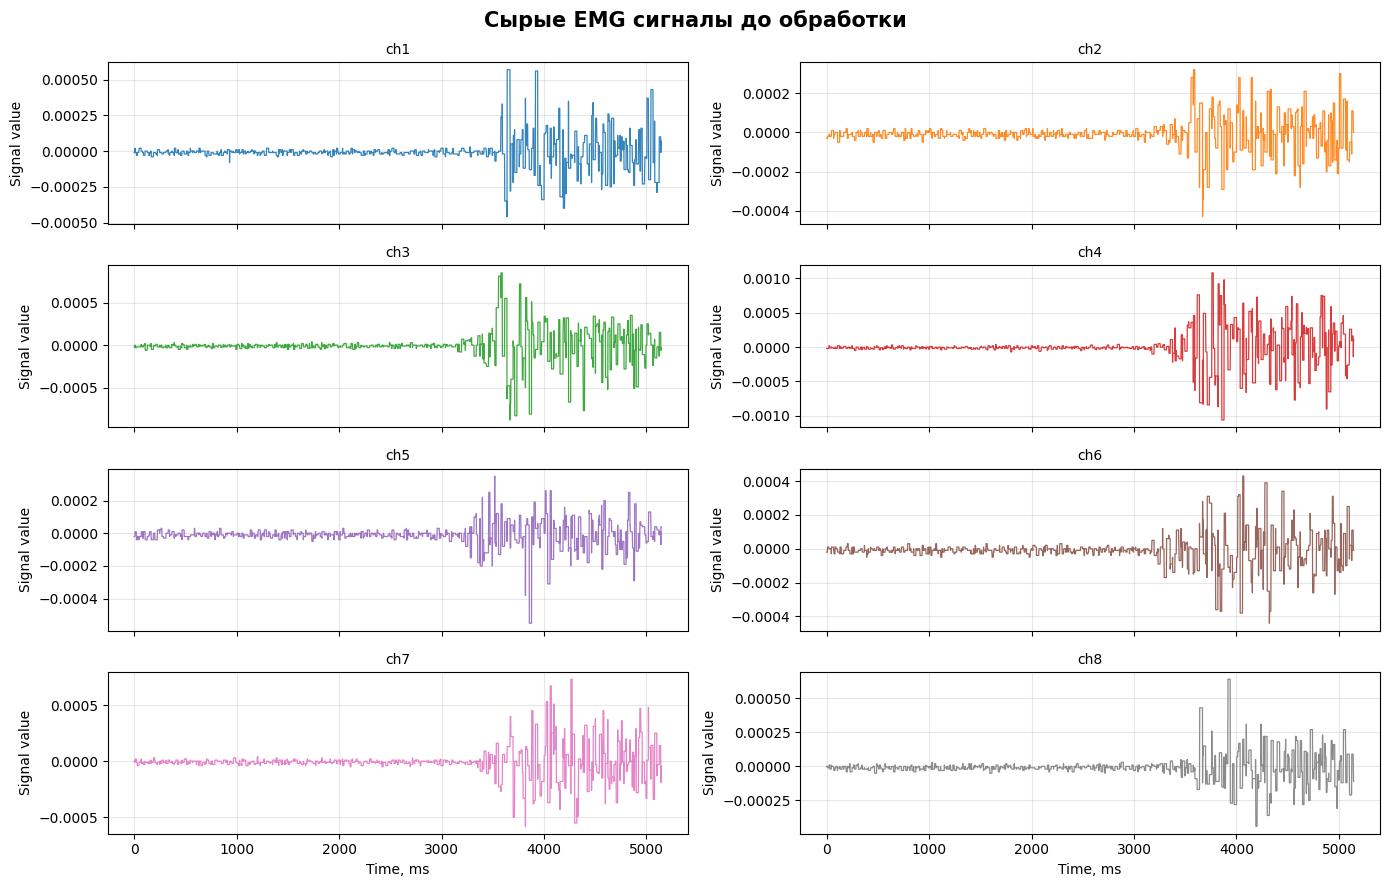

In [14]:
emg_channels = ["ch1", "ch2", "ch3", "ch4", "ch5", "ch6", "ch7", "ch8"]
df_plot = data_raw.iloc[:5000].copy()

if "time" in df_plot.columns:
    x = df_plot["time"]
    x_label = "Time, ms"
else:
    x = df_plot.index
    x_label = "Sample index"

colors = plt.cm.tab10.colors[:8]

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(14, 9), sharex=True)
axs = axs.ravel()

for i, ch in enumerate(emg_channels):
    axs[i].plot(
        x,
        df_plot[ch],
        color=colors[i],
        linewidth=0.9,
        alpha=0.9
    )

    axs[i].set_title(f"{ch}", fontsize=10)
    axs[i].set_ylabel("Signal value")
    axs[i].grid(alpha=0.3)

for ax in axs[6:]:
    ax.set_xlabel(x_label)

plt.suptitle(
    "Сырые EMG сигналы до обработки",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

###Представлен фрагмент исходного EMG-сигнала до предобработки. Сигнал содержит 8 каналов, соответствующих восьми электродам EMG. В начале амплитуда сигнала близка к нулю, что соответствует состоянию покоя. Далее наблюдается увеличение амплитуды и колебаний, что отражает мышечную активность при выполнении жеста.

In [15]:
data_raw.describe()

,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label
count,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06,4.237907e+06
mean,3.113688e+04,-7.911478e-06,-9.416073e-06,-9.548730e-06,-9.637835e-06,-1.599724e-05,-1.085528e-05,-9.364639e-06,-9.696860e-06,1.265671e+00
std,1.868077e+04,1.631111e-04,1.192229e-04,1.241846e-04,2.257728e-04,2.724188e-04,2.151405e-04,1.527311e-04,1.720934e-04,1.989693e+00
min,0.000000e+00,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,0.000000e+00
25%,1.529000e+04,-3.000000e-05,-4.000000e-05,-4.000000e-05,-6.000000e-05,-8.000000e-05,-6.000000e-05,-4.000000e-05,-3.000000e-05,0.000000e+00
50%,3.054600e+04,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,0.000000e+00
75%,4.580400e+04,2.000000e-05,2.000000e-05,3.000000e-05,4.000000e-05,5.000000e-05,3.000000e-05,2.000000e-05,1.000000e-05,2.000000e+00
max,9.714300e+04,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,7.000000e+00


In [16]:
data_raw.nunique()

,0
time,84830
ch1,256
ch2,256
ch3,256
ch4,256
ch5,256
ch6,256
ch7,256
ch8,256
label,8


In [17]:
print("Количество пользователей:", data_raw["subject"].nunique())
print("Пользователи:", sorted(data_raw["subject"].unique()))

Количество пользователей: 36
Пользователи: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36']


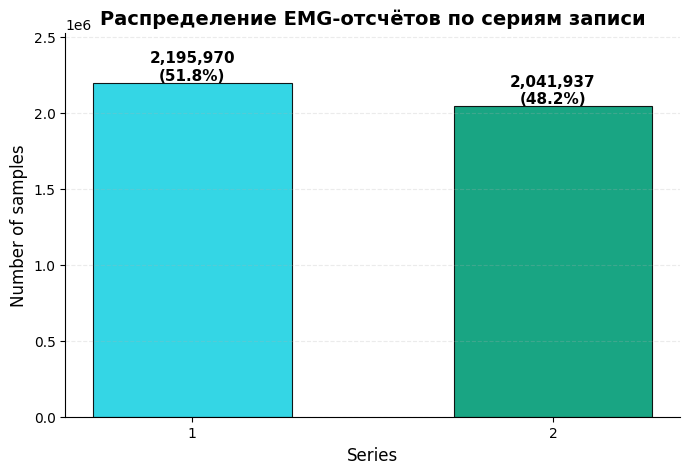

In [18]:
series_counts = data_raw["series"].astype(str).value_counts().sort_index()
series_percent = series_counts / series_counts.sum() * 100

colors = ["#1ed2e3", "#009b76"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    series_counts.index,
    series_counts.values,
    color=colors,
    width=0.55,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8
)

for bar, count, percent in zip(bars, series_counts.values, series_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Распределение EMG-отсчётов по сериям записи",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Series", fontsize=12)
ax.set_ylabel("Number of samples", fontsize=12)

ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_ylim(0, series_counts.max() * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
data_raw["label"].value_counts().sort_index()

,count
label,
0,2725157
1,250055
2,243193
3,249494
4,251570
5,251733
6,253009
7,13696


In [20]:
data_raw.isna().sum()

,0
time,0
ch1,0
ch2,0
ch3,0
ch4,0
ch5,0
ch6,0
ch7,0
ch8,0
label,0


In [21]:
data_raw = data_raw.dropna().copy()

In [22]:
print(data_raw["label"].value_counts().sort_index())

label
0    2725157
1     250055
2     243193
3     249494
4     251570
5     251733
6     253009
7      13696
Name: count, dtype: int64


In [23]:
data = data_raw.copy()

data = data[data["label"] != 0].copy()
data = data[data["label"] != 7].copy()

print("После фильтрации:")
print(data["label"].value_counts().sort_index())
print("Размер:", data.shape)

После фильтрации:
label
1    250055
2    243193
3    249494
4    251570
5    251733
6    253009
Name: count, dtype: int64
Размер: (1499054, 13)


In [24]:
emg_channels = [
    "ch1", "ch2", "ch3", "ch4",
    "ch5", "ch6", "ch7", "ch8"
]

data[emg_channels].describe()

#каналы ch4, ch5, ch6, ch8 в среднем более активны при жестах

,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8
count,1.499054e+06,1.499054e+06,1.499054e+06,1.499054e+06,1.499054e+06,1.499054e+06,1.499054e+06,1.499054e+06
mean,-8.073265e-06,-9.673487e-06,-9.623436e-06,-9.399862e-06,-1.904691e-05,-1.172093e-05,-9.902805e-06,-1.043682e-05
std,1.895366e-04,1.370000e-04,1.379737e-04,2.644814e-04,3.159821e-04,2.491411e-04,1.767302e-04,2.001988e-04
min,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03,-1.280000e-03
25%,-5.000000e-05,-5.000000e-05,-5.000000e-05,-8.000000e-05,-1.300000e-04,-9.000000e-05,-6.000000e-05,-6.000000e-05
50%,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05,-1.000000e-05
75%,4.000000e-05,3.000000e-05,4.000000e-05,6.000000e-05,9.000000e-05,7.000000e-05,4.000000e-05,4.000000e-05
max,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03,1.270000e-03


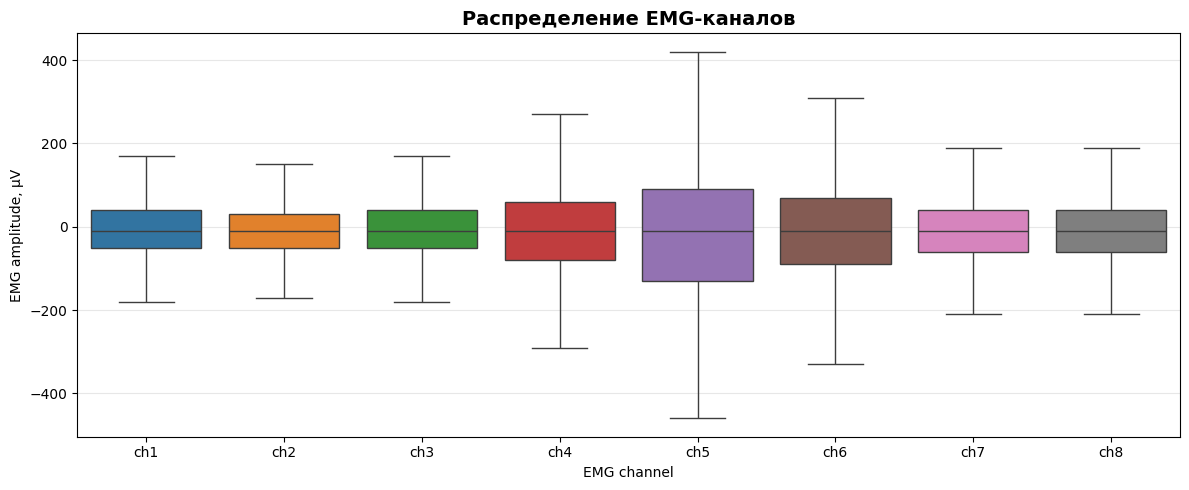

In [25]:
emg_channels = ["ch1", "ch2", "ch3", "ch4", "ch5", "ch6", "ch7", "ch8"]

data_uv = data[emg_channels] * 1e6

plt.figure(figsize=(12, 5))
sns.boxplot(data=data_uv, showfliers=False)

plt.title("Распределение EMG-каналов", fontsize=14, fontweight="bold")
plt.xlabel("EMG channel")
plt.ylabel("EMG amplitude, μV")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

###на графике выше ch1–ch8 распределены около нуля, у всех каналов есть выбросы, ch4, ch5, ch6 выглядят более “широкими”, значит активность там выше.

/tmp/ipykernel_645/3538195021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


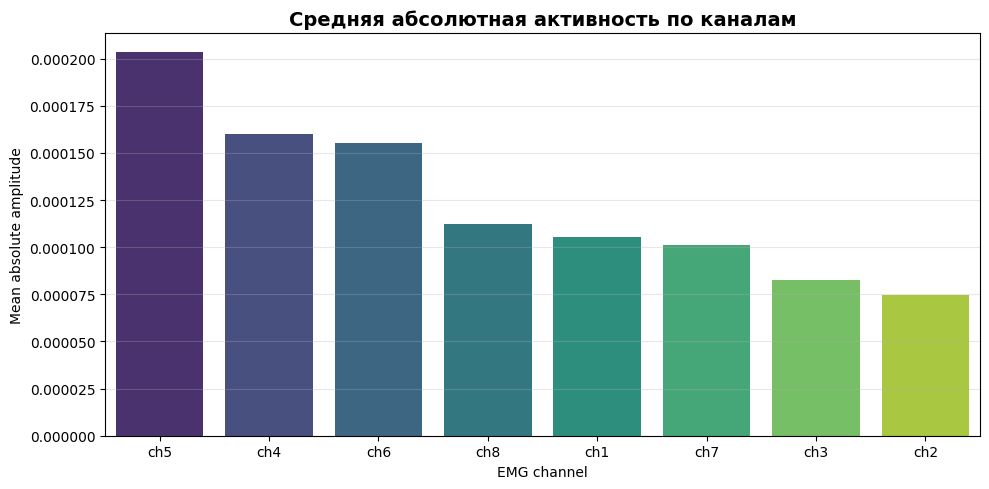

In [26]:
channel_activity = data[emg_channels].abs().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

colors = sns.color_palette("viridis", n_colors=len(channel_activity))

sns.barplot(
    x=channel_activity.index,
    y=channel_activity.values,
    palette=colors
)

plt.title("Средняя абсолютная активность по каналам", fontsize=14, fontweight="bold")
plt.xlabel("EMG channel")
plt.ylabel("Mean absolute amplitude")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
for ch in emg_channels:
    print(ch, data[ch].min(), data[ch].max())

ch1 -0.00128 0.00127
ch2 -0.00128 0.00127
ch3 -0.00128 0.00127
ch4 -0.00128 0.00127
ch5 -0.00128 0.00127
ch6 -0.00128 0.00127
ch7 -0.00128 0.00127
ch8 -0.00128 0.00127


###Значения EMG-каналов находятся в диапазоне примерно от -0.00128 до 0.00127, что указывает на ограниченный диапазон регистрации сигнала датчиком. Для более удобной визуализации амплитуды сигналов были представлены в микровольтах. Основная часть значений сосредоточена около нуля, тогда как отклонения большей амплитуды соответствуют периодам мышечной активности.

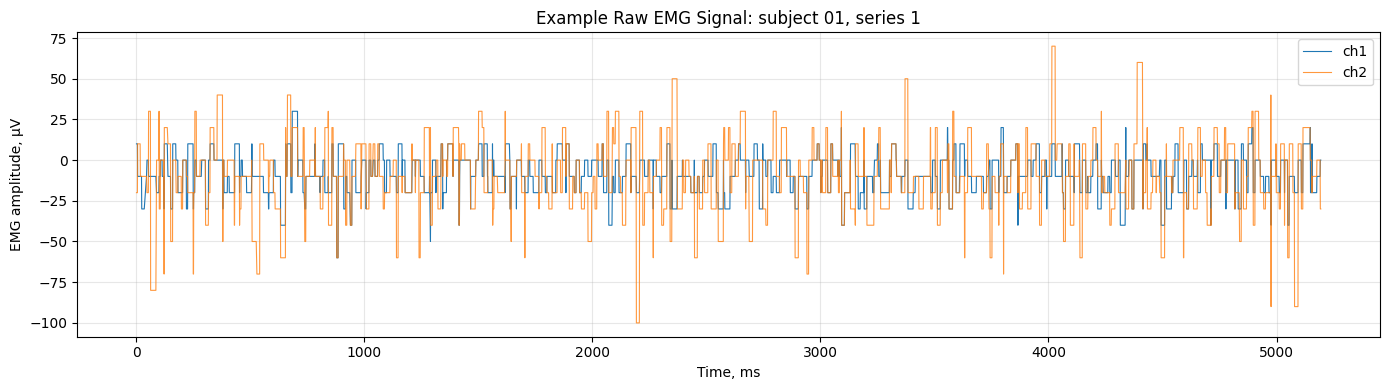

In [28]:
sample_subject = "01"
sample_series = "1"

sample = data_raw[
    (data_raw["subject"] == sample_subject) &
    (data_raw["series"] == sample_series)
].copy()

sample = sample.sort_values("time").iloc[:5000]

plt.figure(figsize=(14, 4))

plt.plot(
    sample["time"],
    sample["ch1"] * 1e6,
    label="ch1",
    linewidth=0.8
)

plt.plot(
    sample["time"],
    sample["ch2"] * 1e6,
    label="ch2",
    linewidth=0.8,
    alpha=0.8
)

plt.xlabel("Time, ms")
plt.ylabel("EMG amplitude, μV")
plt.title(f"Example Raw EMG Signal: subject {sample_subject}, series {sample_series}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
emg_channels = [
    "ch1", "ch2", "ch3", "ch4",
    "ch5", "ch6", "ch7", "ch8"
]

sample_subject = "01"
sample_series = "1"

sample = data_raw[
    (data_raw["subject"] == sample_subject) &
    (data_raw["series"] == sample_series)
].copy()

sample = sample.sort_values("time")

print(sample.shape)
sample.head()

(63196, 13)


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label,subject,series,file_id
3217586,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,01,1,01_1
3217587,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,01,1,01_1
3217588,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1
3217589,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1
3217590,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1


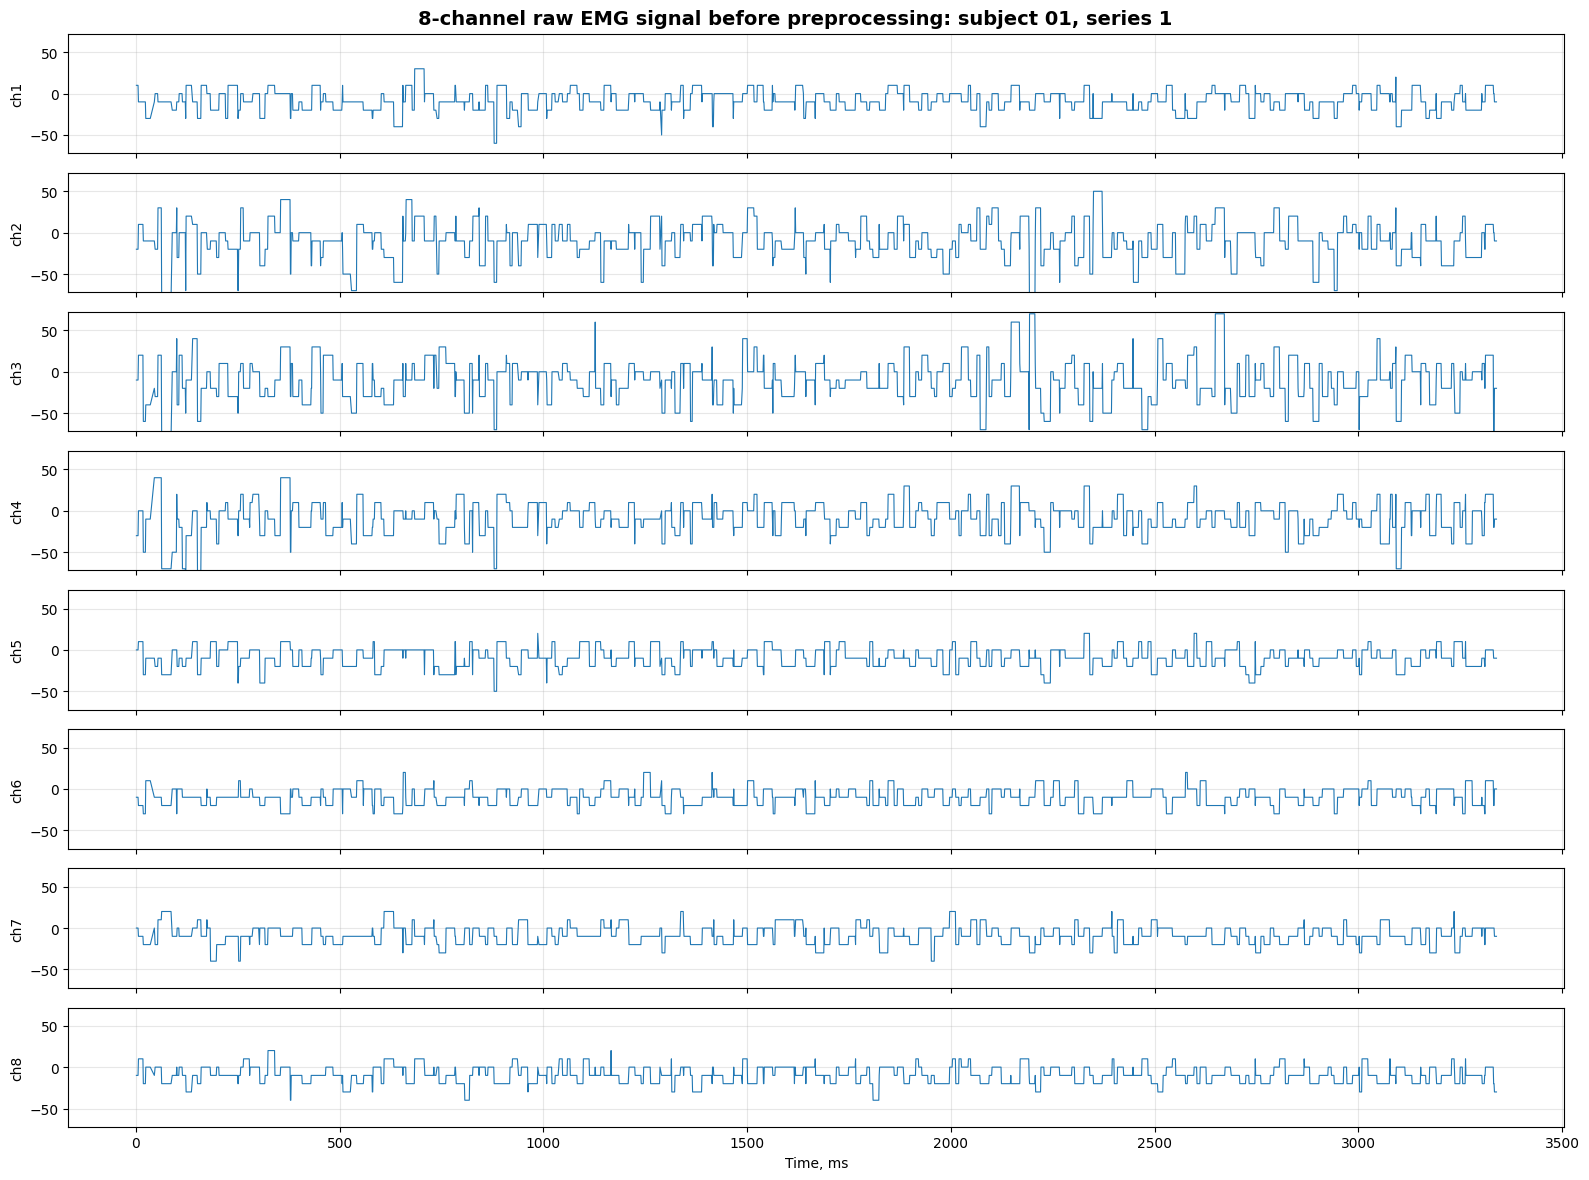

In [30]:
emg_channels = ["ch1", "ch2", "ch3", "ch4", "ch5", "ch6", "ch7", "ch8"]

sample_subject = "01"
sample_series = "1"

sample_full = data_raw[
    (data_raw["subject"] == sample_subject) &
    (data_raw["series"] == sample_series)
].copy()

sample_full = sample_full.sort_values("time").reset_index(drop=True)
sample_part = sample_full.iloc[:3200].copy()

sample_uv = sample_part.copy()
sample_uv[emg_channels] = sample_uv[emg_channels] * 1e6

y_abs_max = np.percentile(np.abs(sample_uv[emg_channels].values), 99)
y_lim = y_abs_max * 1.2

fig, axes = plt.subplots(8, 1, figsize=(16, 12), sharex=True)

for i, ch in enumerate(emg_channels):
    axes[i].plot(
        sample_uv["time"],
        sample_uv[ch],
        linewidth=0.8,
        color="#1f77b4"
    )
    axes[i].set_ylabel(ch)
    axes[i].set_ylim(-y_lim, y_lim)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time, ms")

plt.suptitle(
    f"8-channel raw EMG signal before preprocessing: subject {sample_subject}, series {sample_series}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### На графиках представлены фрагменты восьмиканального EMG-сигнала до предобработки. Каждый подграфик соответствует одному EMG-каналу. Амплитуда сигнала представлена в микровольтах. Видно, что значения сигнала колеблются около нуля, а при выполнении жеста амплитуда отдельных каналов возрастает.

In [31]:
def estimate_sampling_rate(df):
    rows = []

    for file_id, group in df.groupby("file_id"):
        t = group.sort_values("time")["time"].values.astype(float)
        dt = np.diff(t)
        dt = dt[dt > 0]

        median_dt = np.median(dt)
        mean_dt = np.mean(dt)
        fs_median = 1000 / median_dt
        fs_mean = 1000 / mean_dt

        rows.append({
            "file_id": file_id,
            "median_dt": median_dt,
            "mean_dt": mean_dt,
            "fs_median_hz": fs_median,
            "fs_mean_hz": fs_mean
        })

    return pd.DataFrame(rows)

fs_df = estimate_sampling_rate(data_raw)

fs_df.head()

,file_id,median_dt,mean_dt,fs_median_hz,fs_mean_hz
0,01_1,1.0,1.039006,1000.0,962.458118
1,01_2,1.0,1.046177,1000.0,955.861500
2,02_1,1.0,1.030461,1000.0,970.439053
3,02_2,1.0,1.033259,1000.0,967.811580
4,03_1,1.0,1.038963,1000.0,962.498511


In [32]:
fs = int(round(fs_df["fs_median_hz"].median()))

print("Estimated sampling frequency:", fs, "Hz")

Estimated sampling frequency: 1000 Hz


### Перед выполнением фильтрации и оконного разбиения, была проведена оценка временной структуры записей. Для каждого raw-файла рассчитывалась разница между соседними временными отсчётами, после чего определялись медианный и средний временной шаг. Медианный шаг времени между соседними отсчётами составил 1 мс, что соответствует частоте дискретизации около 1000 Гц. Это позволяет использовать полосу фильтрации до 450 Гц, поскольку частота Найквиста составляет 500 Гц.

In [33]:
#проверка качества временной структуры
gap_stats = []

for file_id, group in data_raw.groupby("file_id"):
    t = group.sort_values("time")["time"].values.astype(float)
    dt = np.diff(t)

    gap_stats.append({
        "file_id": file_id,
        "n_samples": len(t),
        "dt_1_count": np.sum(dt == 1),
        "dt_not_1_count": np.sum(dt != 1),
        "max_dt": dt.max(),
        "percent_irregular": np.mean(dt != 1) * 100
    })

gap_stats_df = pd.DataFrame(gap_stats)

gap_stats_df.describe()

,n_samples,dt_1_count,dt_not_1_count,max_dt,percent_irregular
count,72.000000,72.000000,72.000000,72.000000,72.000000
mean,58859.819444,57040.611111,1818.208333,203.930556,3.096505
std,8200.273866,7975.972593,380.804742,1628.118938,0.522411
min,44927.000000,42990.000000,1331.000000,5.000000,2.474671
25%,52023.000000,50566.000000,1511.250000,9.000000,2.715944
50%,57907.500000,56230.500000,1773.500000,10.000000,2.935466
75%,62876.500000,61113.500000,1962.250000,12.000000,3.276578
max,79764.000000,77166.000000,3086.000000,13827.000000,4.588527


In [34]:
gap_stats_df.sort_values("max_dt", ascending=False).head(10)

,file_id,n_samples,dt_1_count,dt_not_1_count,max_dt,percent_irregular
66,34_1,79764,77166,2597,13827.0,3.255896
63,32_2,60211,58389,1821,48.0,3.024415
28,15_1,53553,52153,1399,36.0,2.612414
70,36_1,52390,50674,1715,27.0,3.273588
36,19_1,58818,57008,1809,24.0,3.075641
4,03_1,56568,54777,1790,18.0,3.164389
46,24_1,61968,60357,1610,18.0,2.598157
31,16_2,50012,48659,1352,18.0,2.703405
68,35_1,50417,49085,1331,17.0,2.640035
41,21_2,56882,54271,2610,16.0,4.588527


In [35]:
#сегментация по временным разрывам
def add_time_segments(df, max_gap_ms=10):
    df = df.copy()
    segmented_parts = []

    for file_id, group in tqdm(df.groupby("file_id")):
        group = group.sort_values("time").copy()

        t = group["time"].values.astype(float)
        dt = np.diff(t)

        new_segment_flag = np.concatenate(
            [[0], (dt > max_gap_ms).astype(int)]
        )

        local_segment_id = np.cumsum(new_segment_flag)

        group["segment_id"] = [
            f"{file_id}_seg{seg}" for seg in local_segment_id
        ]

        segmented_parts.append(group)

    data_segmented = pd.concat(segmented_parts, ignore_index=True)
    return data_segmented

In [36]:
data_segmented = add_time_segments(data_raw, max_gap_ms=10)

print("Размер data_segmented:", data_segmented.shape)
print("Количество файлов:", data_segmented["file_id"].nunique())
print("Количество сегментов:", data_segmented["segment_id"].nunique())

data_segmented.head()

100%|██████████| 72/72 [00:02<00:00, 29.70it/s]


Размер data_segmented: (4237907, 14)
Количество файлов: 72
Количество сегментов: 146


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label,subject,series,file_id,segment_id
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,01,1,01_1,01_1_seg0
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,01,1,01_1,01_1_seg0
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1,01_1_seg0
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1,01_1_seg0
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,01,1,01_1,01_1_seg0


In [37]:
segment_sizes = data_segmented.groupby("segment_id").size()

print(segment_sizes.describe())
print("Самые маленькие сегменты:")
print(segment_sizes.sort_values().head(10))

count      146.000000
mean     29026.760274
std      25380.369803
min          1.000000
25%       2348.250000
50%      26299.000000
75%      53055.500000
max      77564.000000
dtype: float64
Самые маленькие сегменты:
segment_id
07_1_seg0     1
15_1_seg0     1
34_1_seg3     1
34_1_seg7     1
31_1_seg2    21
26_2_seg0    30
17_1_seg0    31
32_1_seg1    38
32_1_seg3    65
36_1_seg3    67
dtype: int64


In [38]:
emg_channels = [
    "ch1", "ch2", "ch3", "ch4",
    "ch5", "ch6", "ch7", "ch8"
]

fs = 1000

In [39]:
def filter_emg_by_segment(
    df,
    channels,
    fs=1000,
    lowcut=10,
    highcut=450,
    notch_freq=50
):
    df_filtered = df.copy()

    #  фильтр Баттерворта 6-го порядка
    sos = butter(
        N=6,
        Wn=[lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    # фильтр
    b_notch, a_notch = iirnotch(
        w0=notch_freq,
        Q=30,
        fs=fs
    )

    for segment_id, group in tqdm(df.groupby("segment_id")):
        group = group.sort_values("time")
        idx = group.index

        signal = group[channels].values.astype(float)

        if len(signal) < 500:
            continue

        filtered_signal = sosfiltfilt(sos, signal, axis=0)
        filtered_signal = filtfilt(
            b_notch,
            a_notch,
            filtered_signal,
            axis=0
        )

        df_filtered.loc[idx, channels] = filtered_signal

    return df_filtered

In [40]:
#фильтрует каждый сегмент отдельно
data_filtered = filter_emg_by_segment(
    data_segmented,
    channels=emg_channels,
    fs=1000,
    lowcut=10,
    highcut=450,
    notch_freq=50
)

print(data_filtered.shape)
data_filtered.head()

100%|██████████| 146/146 [00:13<00:00, 10.54it/s]

(4237907, 14)


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label,subject,series,file_id,segment_id
0,1,8.391196e-08,-0.000008,-0.000006,-0.000007,-3.538573e-07,-2.630636e-08,-8.024627e-07,-0.000001,0,01,1,01_1,01_1_seg0
1,5,1.320267e-06,-0.000009,-0.000007,-0.000010,-4.624472e-07,-3.181583e-07,-5.359421e-07,-0.000002,0,01,1,01_1,01_1_seg0
2,6,-1.731157e-05,0.000020,0.000024,0.000018,9.729972e-06,-9.882344e-06,-9.909931e-06,0.000018,0,01,1,01_1,01_1_seg0
3,7,-1.650585e-05,0.000020,0.000024,0.000015,9.409121e-06,-1.082051e-05,-9.941744e-06,0.000017,0,01,1,01_1,01_1_seg0
4,8,-1.520696e-05,0.000019,0.000025,0.000014,1.015181e-05,-9.758946e-06,-8.941177e-06,0.000017,0,01,1,01_1,01_1_seg0


In [41]:
#задаётся оконное разбиение
fs = 1000

window_ms = 200
overlap = 0.5

window_size = int(fs * window_ms / 1000)
step = int(window_size * (1 - overlap))

print("window_size:", window_size)
print("step:", step)

window_size: 200
step: 100


###Выводы:
На этапе предобработки данных был проведён рекурсивный поиск файлов в папке `Raw`. Всего было обнаружено 73 текстовых файла, из которых 72 файла содержали исходные EMG-записи с названием `raw_data`. Это соответствует структуре набора данных: 36 пользователей, по две серии записи для каждого пользователя. Один дополнительный текстовый файл не относился к raw EMG-сигналам.

Каждый raw-файл представлял собой временной ряд, включающий колонку времени, восемь EMG-каналов и метку класса. Для унификации структуры данных все файлы были приведены к единому формату: `time`, `ch1`–`ch8`, `label`, `subject`, `series`, `file_id`. Дополнительные признаки `subject`, `series` и `file_id` были добавлены для сохранения информации о пользователе, серии записи и принадлежности каждой строки к конкретному файлу. После объединения всех 72 raw-файлов был получен общий датасет `data_raw` размером 4 237 907 строк и 13 столбцов. Проверка типов данных показала, что временная метка и метка класса имеют целочисленный тип, значения EMG-каналов представлены вещественными числами, а идентификаторы пользователя, серии и файла — строковыми признаками. Пропущенные значения в данных отсутствовали.

На этапе первичного анализа было установлено, что исходные метки находятся в диапазоне от 0 до 7. При этом метка 0 составляла основную часть записей и соответствовала нецелевому состоянию, а метка 7 встречалась значительно реже остальных классов. Для основной задачи классификации в качестве целевых классов были выбраны метки 1–6, соответствующие шести жестам.

Перед фильтрацией была выполнена оценка частоты дискретизации. Было установлено, что большая часть соседних отсчётов имеет шаг 1 мс, однако в отдельных файлах присутствуют нерегулярные интервалы и длинные временные разрывы. Максимальный разрыв составил 13827 мс в файле `34_1`.

Для исключения некорректного формирования окон через временные разрывы была выполнена сегментация по времени. Если интервал между соседними отсчётами превышал 10 мс, начинался новый временной сегмент. В результате каждому непрерывному участку записи был присвоен отдельный `segment_id`. После сегментации были обнаружены отдельные очень короткие сегменты, состоящие из малого числа отсчётов. Такие сегменты возникали на границах временных разрывов и не отражали полноценные фрагменты EMG-записи. В дальнейшем они не использовались для фильтрации и оконного разбиения.

После сегментации была выполнена фильтрация EMG-сигнала отдельно внутри каждого временного сегмента. Такой подход позволил избежать искажения сигнала на границах длинных разрывов. Для очистки сигнала использовался полосовой фильтр в диапазоне 10–450 Гц, что позволило сохранить основную информативную область EMG-сигнала и уменьшить влияние низкочастотных и высокочастотных помех. Дополнительно применялось подавление сетевой помехи на частоте 50 Гц. Короткие сегменты, длина которых была недостаточна для корректной фильтрации, пропускались. В результате был сформирован датасет `data_filtered`, сохранивший исходную структуру данных, но содержащий уже отфильтрованные значения EMG-каналов.

После завершения фильтрации был выполнен переход к оконному представлению сигнала. При частоте дискретизации 1000 Гц использовались окна длительностью 200 мс, что соответствует 200 отсчётам. Перекрытие между соседними окнами составляло 50%, поэтому шаг окна был равен 100 отсчётам.

## 5.Feature Engineering

In [42]:
#признак показывает среднюю силу активности мышцы в окне
def compute_mav(signal_1d):
    return np.mean(np.abs(signal_1d))

#медианная частота спектра - в какой частотной области сосредоточена энергия сигнала
def compute_mdf(signal_1d, fs=1000):
    signal_1d = signal_1d - np.mean(signal_1d)

    fft_values = np.fft.rfft(signal_1d)  #спектр мощности
    power_spectrum = np.abs(fft_values) ** 2
    freqs = np.fft.rfftfreq(len(signal_1d), d=1/fs)

    total_power = np.sum(power_spectrum)

    if total_power <= 0:
        return 0.0

    cumulative_power = np.cumsum(power_spectrum)
    median_idx = np.searchsorted(cumulative_power, total_power / 2)

    return freqs[median_idx]

In [43]:
valid_labels = {1, 2, 3, 4, 5, 6}

def create_mav_mdf_dataset_all_channels(df, channels, fs=1000, window_size=200, step=100, purity_threshold=0.9, min_segment_len_for_filtered=500):
    X_features = []
    y_labels = []
    subjects = []
    series_ids = []
    file_ids = []
    segment_ids = []

    for segment_id, group in tqdm(df.groupby("segment_id")):
        group = group.sort_values("time").reset_index(drop=True)

        if len(group) < max(window_size, min_segment_len_for_filtered):
            continue

        signal = group[channels].values.astype(np.float32)
        labels = group["label"].values.astype(int)

        subject = group["subject"].iloc[0]
        series = group["series"].iloc[0]
        file_id = group["file_id"].iloc[0]

        for start in range(0, len(group) - window_size + 1, step):
            end = start + window_size

            window_signal = signal[start:end]
            window_labels = labels[start:end]

            counts = np.bincount(window_labels)
            main_label = counts.argmax()
            purity = np.mean(window_labels == main_label)

            if main_label in valid_labels and purity >= purity_threshold:
                feature_vector = []

                for ch_idx in range(len(channels)):
                    channel_signal = window_signal[:, ch_idx]

                    mav = compute_mav(channel_signal)
                    mdf = compute_mdf(channel_signal, fs=fs)

                    feature_vector.extend([mav, mdf])

                X_features.append(feature_vector)
                y_labels.append(main_label)
                subjects.append(subject)
                series_ids.append(series)
                file_ids.append(file_id)
                segment_ids.append(segment_id)

    return (
        np.array(X_features, dtype=np.float32),
        np.array(y_labels, dtype=np.int64),
        np.array(subjects),
        np.array(series_ids),
        np.array(file_ids),
        np.array(segment_ids)
    )

In [44]:
X_mav_mdf, y_mav_mdf, subjects_mav_mdf, series_mav_mdf, file_ids_mav_mdf, segment_ids_mav_mdf = create_mav_mdf_dataset_all_channels(
    data_filtered,
    channels=emg_channels,
    fs=fs,
    window_size=window_size,
    step=step,
    purity_threshold=0.9
)

print("X_mav_mdf:", X_mav_mdf.shape)
print("y_mav_mdf:", y_mav_mdf.shape)

print("Классы:")
print(pd.Series(y_mav_mdf).value_counts().sort_index())

print("Пользователей:", len(np.unique(subjects_mav_mdf)))
print("Файлов:", len(np.unique(file_ids_mav_mdf)))
print("Сегментов:", len(np.unique(segment_ids_mav_mdf)))

100%|██████████| 146/146 [00:08<00:00, 17.48it/s]

X_mav_mdf: (13629, 16)
y_mav_mdf: (13629,)
Классы:
1    2264
2    2206
3    2268
4    2292
5    2292
6    2307
Name: count, dtype: int64
Пользователей: 36
Файлов: 72
Сегментов: 109


In [45]:
feature_names = []

for ch in emg_channels:
    feature_names.append(f"{ch}_MAV")
    feature_names.append(f"{ch}_MDF")

features_df = pd.DataFrame(X_mav_mdf, columns=feature_names)

features_df["label"] = y_mav_mdf
features_df["subject"] = subjects_mav_mdf
features_df["series"] = series_mav_mdf
features_df["file_id"] = file_ids_mav_mdf
features_df["segment_id"] = segment_ids_mav_mdf

features_df.head()

,ch1_MAV,ch1_MDF,ch2_MAV,ch2_MDF,ch3_MAV,ch3_MDF,ch4_MAV,ch4_MDF,ch5_MAV,ch5_MDF,...,ch6_MDF,ch7_MAV,ch7_MDF,ch8_MAV,ch8_MDF,label,subject,series,file_id,segment_id
0,0.000006,30.0,0.000017,35.0,0.000019,30.0,0.000013,40.0,0.000009,40.0,...,30.0,0.000005,35.0,0.000008,15.0,1,01,1,01_1,01_1_seg0
1,0.000007,30.0,0.000018,25.0,0.000026,20.0,0.000009,35.0,0.000008,40.0,...,30.0,0.000005,25.0,0.000006,35.0,1,01,1,01_1,01_1_seg0
2,0.000007,30.0,0.000017,15.0,0.000026,20.0,0.000009,40.0,0.000008,35.0,...,30.0,0.000007,25.0,0.000006,30.0,1,01,1,01_1,01_1_seg0
3,0.000008,30.0,0.000016,25.0,0.000022,30.0,0.000011,35.0,0.000006,30.0,...,30.0,0.000006,30.0,0.000006,20.0,1,01,1,01_1,01_1_seg0
4,0.000006,30.0,0.000014,25.0,0.000018,35.0,0.000010,30.0,0.000005,35.0,...,20.0,0.000006,30.0,0.000007,35.0,1,01,1,01_1,01_1_seg0


In [46]:
features_df.shape

(13629, 21)

In [47]:
features_df["label"].value_counts().sort_index()

,count
label,
1,2264
2,2206
3,2268
4,2292
5,2292
6,2307


In [48]:
features_df.describe()

,ch1_MAV,ch1_MDF,ch2_MAV,ch2_MDF,ch3_MAV,ch3_MDF,ch4_MAV,ch4_MDF,ch5_MAV,ch5_MDF,ch6_MAV,ch6_MDF,ch7_MAV,ch7_MDF,ch8_MAV,ch8_MDF,label
count,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000,13629.000000
mean,0.000087,28.819063,0.000061,29.098980,0.000068,29.615158,0.000131,29.046885,0.000165,28.615820,0.000127,28.572529,0.000083,28.766968,0.000092,28.780174,3.518233
std,0.000093,9.621252,0.000069,9.094727,0.000062,9.566466,0.000120,9.147110,0.000133,9.053222,0.000108,9.104651,0.000084,9.092480,0.000096,9.445081,1.709465
min,0.000001,10.000000,0.000003,10.000000,0.000004,10.000000,0.000004,10.000000,0.000001,10.000000,0.000002,10.000000,0.000001,10.000000,0.000001,10.000000,1.000000
25%,0.000023,25.000000,0.000021,25.000000,0.000027,25.000000,0.000034,25.000000,0.000052,25.000000,0.000043,25.000000,0.000025,25.000000,0.000021,25.000000,2.000000
50%,0.000051,25.000000,0.000039,30.000000,0.000048,30.000000,0.000091,30.000000,0.000136,25.000000,0.000098,25.000000,0.000058,25.000000,0.000056,25.000000,4.000000
75%,0.000119,35.000000,0.000071,35.000000,0.000087,35.000000,0.000198,35.000000,0.000252,30.000000,0.000186,30.000000,0.000109,35.000000,0.000133,35.000000,5.000000
max,0.000804,175.000000,0.000687,150.000000,0.000645,135.000000,0.000723,135.000000,0.000788,150.000000,0.000709,180.000000,0.000654,155.000000,0.000760,155.000000,6.000000


###Выводы:
На данном этапе из каждого валидного окна были извлечены признаки MAV и MDF по каждому из восьми EMG-каналов. Признак MAV отражал среднюю абсолютную амплитуду сигнала. Признак MDF описывал медианную частоту спектра и позволял учитывать частотную структуру EMG-сигнала. Таким образом, каждое окно было представлено 16-мерным вектором признаков: по два признака для каждого из восьми каналов. В результате был сформирован датасет `X_mav_mdf` размером 13629 × 16 и соответствующий массив меток `y_mav_mdf` размером 13629. Распределение классов после оконного разбиения оказалось близким к сбалансированному: каждый из шести жестов был представлен примерно 2200–2300 окнами.


## 6.Обучение глобальной модели

В глобальных моделях были протестированы как алгоритмы машинного обучения, так и нейросетевые модели. Классические модели включали Logistic Regression и Random Forest. Нейросетевые модели включали MLP Neural Network и 1D-CNN.

Наилучший результат среди глобальных моделей показала 1D-CNN на сырых EMG-окнах: Macro-F1 = 0.8085. Среди моделей на признаках MAV и MDF лучший результат получила MLP Neural Network с Macro-F1 = 0.8010. Random Forest показал близкое качество — Macro-F1 = 0.7979, а Logistic Regression достигла Macro-F1 = 0.7830.

### Логистическая регрессия

In [49]:
unique_subjects = np.array(sorted(np.unique(subjects_mav_mdf)))

train_subjects, test_subjects = train_test_split(
    unique_subjects,
    test_size=0.2,
    random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects,
    test_size=0.25,
    random_state=42
)

print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

train_mask = np.isin(subjects_mav_mdf, train_subjects)
val_mask = np.isin(subjects_mav_mdf, val_subjects)
test_mask = np.isin(subjects_mav_mdf, test_subjects)

X_train = X_mav_mdf[train_mask]
y_train = y_mav_mdf[train_mask]

X_val = X_mav_mdf[val_mask]
y_val = y_mav_mdf[val_mask]

X_test = X_mav_mdf[test_mask]
y_test = y_mav_mdf[test_mask]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Train labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("Val labels:")
print(pd.Series(y_val).value_counts().sort_index())

print("Test labels:")
print(pd.Series(y_test).value_counts().sort_index())

Train subjects: ['26' '02' '03' '04' '18' '01' '05' '10' '33' '07' '35' '15' '21' '28'
 '29' '23' '16' '12' '34' '11' '30']
Val subjects: ['06' '08' '20' '19' '09' '25' '24']
Test subjects: ['36' '14' '27' '31' '17' '32' '22' '13']
X_train: (7925, 16)
X_val: (2562, 16)
X_test: (3142, 16)
Train labels:
1    1322
2    1278
3    1339
4    1330
5    1315
6    1341
Name: count, dtype: int64
Val labels:
1    429
2    427
3    412
4    426
5    435
6    433
Name: count, dtype: int64
Test labels:
1    513
2    501
3    517
4    536
5    542
6    533
Name: count, dtype: int64


In [50]:
#SScaler приводит признаки к единому масштабу
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [51]:
logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_macro_f1 = f1_score(y_test, y_pred_logreg, average="macro")
logreg_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_logreg)

print("Logistic Regression Global Results")
print("Accuracy:", logreg_accuracy)
print("Macro-F1:", logreg_macro_f1)
print("Balanced Accuracy:", logreg_balanced_accuracy)

Logistic Regression Global Results
Accuracy: 0.7835773392743476
Macro-F1: 0.7830330397120567
Balanced Accuracy: 0.7844217816915596


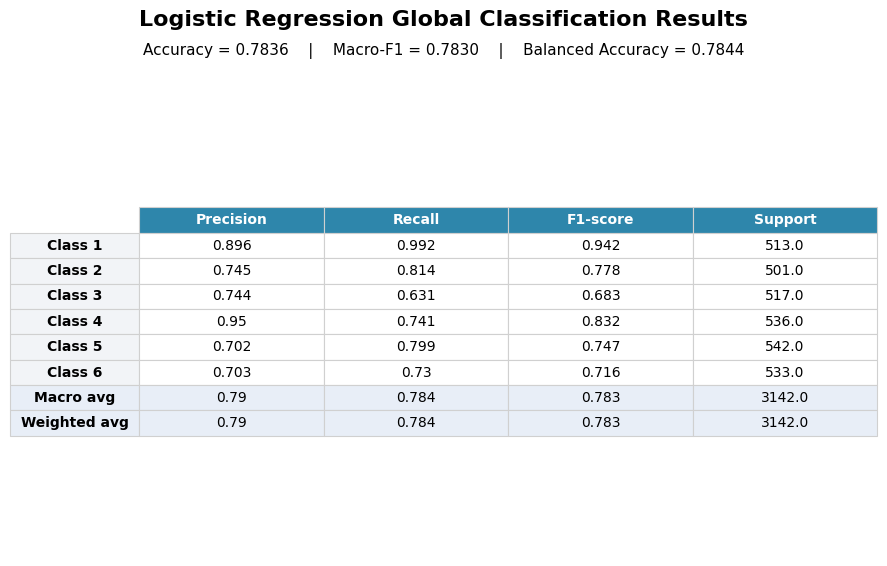

In [52]:
labels = [1, 2, 3, 4, 5, 6]
model_name = "Logistic Regression"

summary_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logreg),
    "Macro-F1": f1_score(y_test, y_pred_logreg, average="macro"),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_logreg)
}

report_dict = classification_report(
    y_test,
    y_pred_logreg,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

report_df = report_df.loc[
    [str(i) for i in labels] + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

report_df["support"] = report_df["support"].astype(int)

display_df = report_df.copy()
display_df[["precision", "recall", "f1-score"]] = display_df[
    ["precision", "recall", "f1-score"]
].round(3)

display_df = display_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

display_df.index = [
    "Class 1", "Class 2", "Class 3",
    "Class 4", "Class 5", "Class 6",
    "Macro avg", "Weighted avg"
]

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.axis("off")

title = f"{model_name} Global Classification Results"

subtitle = (
    f"Accuracy = {summary_metrics['Accuracy']:.4f}    |    "
    f"Macro-F1 = {summary_metrics['Macro-F1']:.4f}    |    "
    f"Balanced Accuracy = {summary_metrics['Balanced Accuracy']:.4f}"
)

fig.text(
    0.5, 0.94,
    title,
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.89,
    subtitle,
    ha="center",
    fontsize=11
)

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_facecolor("#2E86AB")
        cell.set_text_props(color="white", weight="bold")

    if col == -1:
        cell.set_facecolor("#F2F4F7")
        cell.set_text_props(weight="bold")

    if row in [7, 8]:
        cell.set_facecolor("#E8EEF7")

plt.tight_layout(rect=[0, 0, 1, 0.86])

plt.show()

In [53]:
labels = [1, 2, 3, 4, 5, 6]

cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=labels
)

cm_logreg_df = pd.DataFrame(
    cm_logreg,
    index=[f"True_{i}" for i in labels],
    columns=[f"Pred_{i}" for i in labels]
)

print("Матрица ошибок для Logistic Regression:")
print(cm_logreg_df)

Матрица ошибок для Logistic Regression:
        Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6
True_1     509       0       2       0       2       0
True_2      14     408      40       0      34       5
True_3      32      23     326       0       6     130
True_4       0       7       0     397     103      29
True_5      12      84       0      13     433       0
True_6       1      26      70       8      39     389


###Выводы:
Всего в датасете было представлено 36 пользователей. Из них 21 пользователь был отнесён к обучающей выборке, 7 пользователей — к валидационной, и 8 пользователей — к тестовой. После применения масок по пользователям были сформированы выборки X_train, X_val и X_test размером 7925, 2562 и 3142 окна соответственно.

Перед обучением Logistic Regression признаки были стандартизированы с помощью StandardScaler. Параметры стандартизации рассчитывались только на обучающей выборке, после чего применялись к валидационным и тестовым данным. Такой подход позволил избежать утечки информации из тестовой выборки. В качестве первой глобальной модели была обучена Logistic Regression с параметром class_weight="balanced" и увеличенным числом итераций max_iter=3000.

Анализ матрицы ошибок Logistic Regression показал, что модель наиболее уверенно распознаёт класс 1. Из 513 тестовых окон данного класса 509 были классифицированы правильно, что указывает на хорошую отделимость этого жеста по признакам MAV и MDF. Для классов 2 и 5 также наблюдается относительно устойчивое качество распознавания, однако между ними присутствует заметная взаимная путаница: часть окон класса 5 модель относит к классу 2.

Наиболее проблемным оказался класс 3. Из 517 тестовых окон данного класса правильно были классифицированы 326, при этом 130 окон были ошибочно отнесены к классу 6. Это указывает на близость амплитудно-частотных характеристик классов 3 и 6 в пространстве признаков MAV и MDF. Обратная ошибка также присутствует: 70 окон класса 6 были классифицированы как класс 3. Таким образом, пара классов 3 и 6 является одной из основных зон ошибок для Logistic Regression.

Также заметная путаница наблюдается между классами 4 и 5. Из 536 окон класса 4 модель правильно распознала 397, однако 103 окна были отнесены к классу 5. Это может означать, что данные жесты имеют частично сходный характер мышечной активации или недостаточно хорошо разделяются выбранными признаками. При этом класс 4 имеет достаточно высокую точность предсказания, но часть его реальных объектов теряется за счёт перехода в класс 5.

### Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_rf)

print("Random Forest Global Results")
print("Accuracy:", rf_accuracy)
print("Macro-F1:", rf_macro_f1)
print("Balanced Accuracy:", rf_balanced_accuracy)

Random Forest Global Results
Accuracy: 0.7972628898790579
Macro-F1: 0.7979335275108621
Balanced Accuracy: 0.7983228597258604


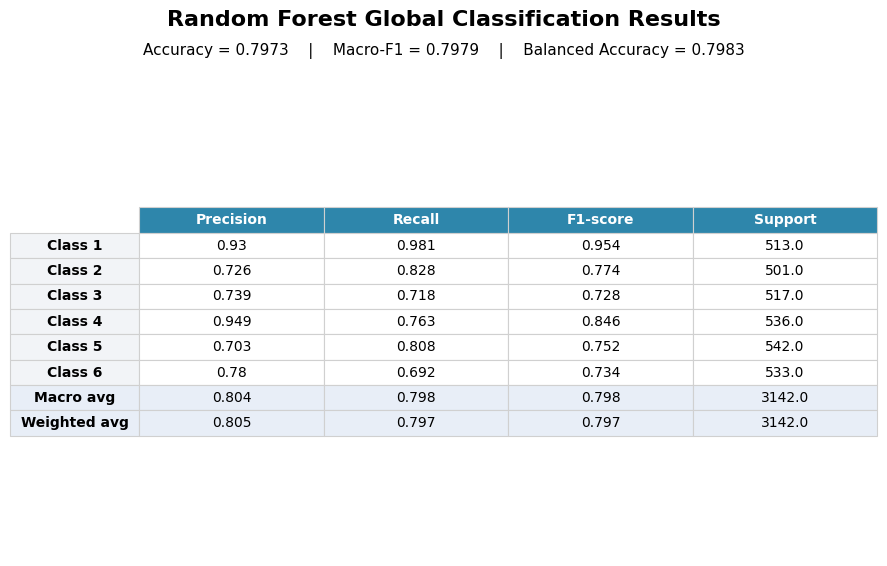

In [ ]:
labels = [1, 2, 3, 4, 5, 6]
model_name = "Random Forest"

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_rf)

summary_metrics = {
    "Accuracy": rf_accuracy,
    "Macro-F1": rf_macro_f1,
    "Balanced Accuracy": rf_balanced_accuracy
}

report_dict = classification_report(
    y_test,
    y_pred_rf,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

report_df = report_df.loc[
    [str(i) for i in labels] + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

report_df["support"] = report_df["support"].astype(int)

display_df = report_df.copy()

display_df[["precision", "recall", "f1-score"]] = display_df[
    ["precision", "recall", "f1-score"]
].round(3)

display_df = display_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

display_df.index = [
    "Class 1", "Class 2", "Class 3",
    "Class 4", "Class 5", "Class 6",
    "Macro avg", "Weighted avg"
]

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.axis("off")

title = f"{model_name} Global Classification Results"

subtitle = (
    f"Accuracy = {summary_metrics['Accuracy']:.4f}    |    "
    f"Macro-F1 = {summary_metrics['Macro-F1']:.4f}    |    "
    f"Balanced Accuracy = {summary_metrics['Balanced Accuracy']:.4f}"
)

fig.text(
    0.5, 0.94,
    title,
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.89,
    subtitle,
    ha="center",
    fontsize=11
)

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_facecolor("#2E86AB")
        cell.set_text_props(color="white", weight="bold")

    if col == -1:
        cell.set_facecolor("#F2F4F7")
        cell.set_text_props(weight="bold")

    if row in [7, 8]:
        cell.set_facecolor("#E8EEF7")

plt.tight_layout(rect=[0, 0, 1, 0.86])

plt.show()

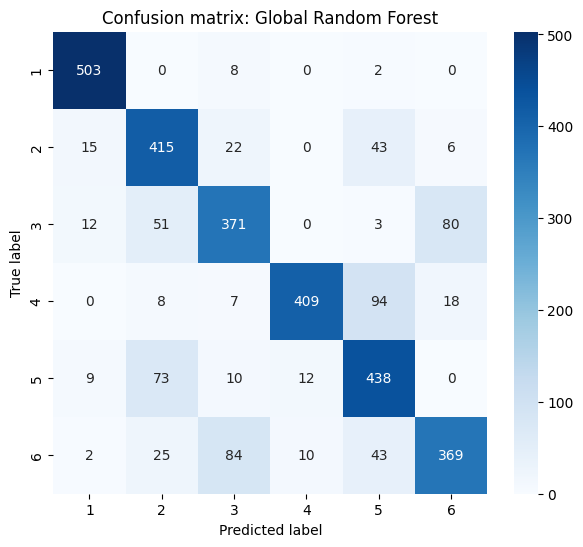

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, 2, 3, 4, 5, 6])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5, 6],
    yticklabels=[1, 2, 3, 4, 5, 6]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix: Global Random Forest")
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, 2, 3, 4, 5, 6])
cm_df = pd.DataFrame(
    cm,
    index=[f'True_{i}' for i in [1, 2, 3, 4, 5, 6]],
    columns=[f'Pred_{i}' for i in [1, 2, 3, 4, 5, 6]]
)

print("Матрица ошибок:")
print(cm_df)

Матрица ошибок:
        Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6
True_1     503       0       8       0       2       0
True_2      15     415      22       0      43       6
True_3      12      51     371       0       3      80
True_4       0       8       7     409      94      18
True_5       9      73      10      12     438       0
True_6       2      25      84      10      43     369


### Выводы:
На тестовой выборке `Random Forest` показал `Accuracy 0.7973`, `Macro-F1 0.7979` и `Balanced Accuracy 0.7983`.

Анализ показал, что лучше всего `Random Forest` распознаёт класс 1, для которого `F1-score` составил 0.954. По матрице ошибок видно, что из 513 тестовых окон класса 1 модель правильно классифицировала 503. Это указывает на высокую отделимость данного жеста по признакам MAV и MDF. Также класс 4 имеет высокую точность предсказания, однако его `recall` ниже, так как часть реальных окон этого класса модель относит к другим жестам, преимущественно к классу 5.

**Основные ошибки** `Random Forest` наблюдались между классами 3 и 6, а также между классами 4 и 5, 5 и 2. Например, 80 окон класса 3 были отнесены к классу 6, а 84 окна класса 6 — к классу 3. Кроме того, 94 окна класса 4 были классифицированы как класс 5. Это показывает, что для некоторых жестов амплитудно-частотные признаки имеют похожую структуру.

### MLP Neural Network

In [58]:
y_train_nn = y_train - 1
y_val_nn = y_val - 1
y_test_nn = y_test - 1

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_nn, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_nn, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [59]:
class EMGMLP(nn.Module):
    def __init__(self, input_dim=16, num_classes=6):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

mlp_model = EMGMLP(
    input_dim=X_train_scaled.shape[1],
    num_classes=6
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Device: cpu


In [61]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def predict_model(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

In [62]:
num_epochs = 80

best_val_f1 = 0
best_state = None
patience = 10
patience_counter = 0

history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        mlp_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    y_val_true, y_val_pred = predict_model(
        mlp_model,
        val_loader,
        device
    )

    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_f1 = f1_score(y_val_true, y_val_pred, average="macro")
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "val_balanced_accuracy": val_bal_acc
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(mlp_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

mlp_model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 001 | Loss: 1.5377 | Val Acc: 0.6304 | Val Macro-F1: 0.6118
Epoch 002 | Loss: 1.0919 | Val Acc: 0.7650 | Val Macro-F1: 0.7610
Epoch 003 | Loss: 0.8473 | Val Acc: 0.8150 | Val Macro-F1: 0.8127
Epoch 004 | Loss: 0.7136 | Val Acc: 0.8236 | Val Macro-F1: 0.8218
Epoch 005 | Loss: 0.6362 | Val Acc: 0.8407 | Val Macro-F1: 0.8391
Epoch 006 | Loss: 0.5918 | Val Acc: 0.8486 | Val Macro-F1: 0.8472
Epoch 007 | Loss: 0.5531 | Val Acc: 0.8556 | Val Macro-F1: 0.8545
Epoch 008 | Loss: 0.5283 | Val Acc: 0.8618 | Val Macro-F1: 0.8611
Epoch 009 | Loss: 0.4933 | Val Acc: 0.8528 | Val Macro-F1: 0.8512
Epoch 010 | Loss: 0.4854 | Val Acc: 0.8575 | Val Macro-F1: 0.8563
Epoch 011 | Loss: 0.4659 | Val Acc: 0.8685 | Val Macro-F1: 0.8676
Epoch 012 | Loss: 0.4523 | Val Acc: 0.8614 | Val Macro-F1: 0.8604
Epoch 013 | Loss: 0.4308 | Val Acc: 0.8712 | Val Macro-F1: 0.8703
Epoch 014 | Loss: 0.4252 | Val Acc: 0.8673 | Val Macro-F1: 0.8659
Epoch 015 | Loss: 0.4172 | Val Acc: 0.8778 | Val Macro-F1: 0.8770
Epoch 016 

,epoch,train_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
61,62,0.296430,0.881343,0.880830,0.880707
62,63,0.298863,0.883685,0.883292,0.883199
63,64,0.303869,0.887588,0.886978,0.886808
64,65,0.301530,0.882514,0.881943,0.881971
65,66,0.288148,0.884075,0.883286,0.883376


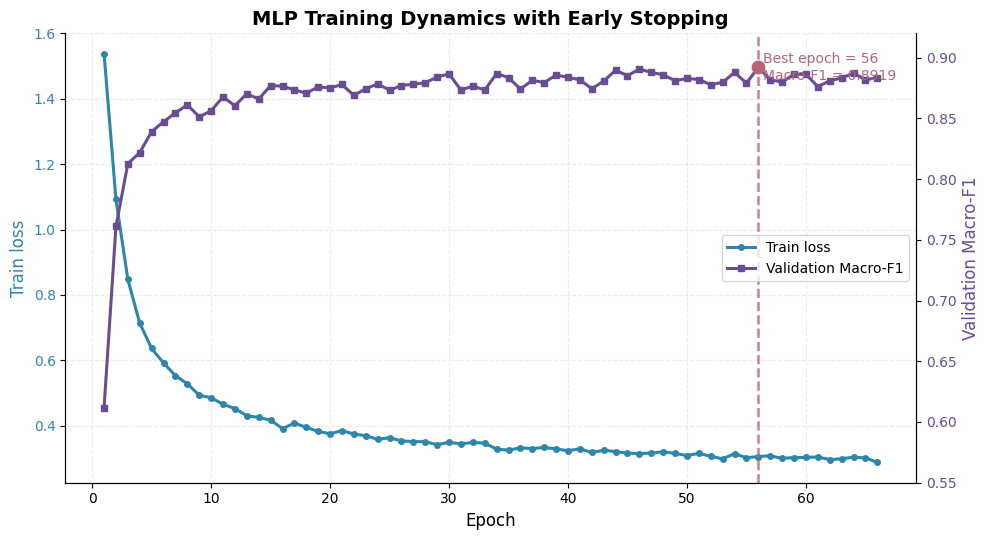

In [63]:
best_idx = history_df["val_macro_f1"].idxmax()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_f1 = history_df.loc[best_idx, "val_macro_f1"]

fig, ax1 = plt.subplots(figsize=(10, 5.5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    color="#2E86AB",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Train loss"
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Train loss", fontsize=12, color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")
ax1.grid(alpha=0.25, linestyle="--")

ax2 = ax1.twinx()

ax2.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    color="#6A4C93",
    linewidth=2.2,
    marker="s",
    markersize=4,
    label="Validation Macro-F1"
)

ax2.set_ylabel("Validation Macro-F1", fontsize=12, color="#6A4C93")
ax2.tick_params(axis="y", labelcolor="#6A4C93")
ax2.set_ylim(0.55, 0.92)

ax1.axvline(
    best_epoch,
    color="#B56576",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)

ax2.scatter(
    best_epoch,
    best_f1,
    color="#B56576",
    s=80,
    zorder=5
)

ax2.text(
    best_epoch + 0.4,
    best_f1,
    f"Best epoch = {best_epoch}\nMacro-F1 = {best_f1:.4f}",
    fontsize=10,
    color="#B56576",
    va="center"
)

plt.title(
    "MLP Training Dynamics with Early Stopping",
    fontsize=14,
    fontweight="bold"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center right",
    frameon=True
)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig("mlp_training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
y_test_true_nn, y_test_pred_nn = predict_model(
    mlp_model,
    test_loader,
    device
)
y_test_true_mlp = y_test_true_nn + 1
y_test_pred_mlp = y_test_pred_nn + 1

mlp_accuracy = accuracy_score(y_test_true_mlp, y_test_pred_mlp)
mlp_macro_f1 = f1_score(y_test_true_mlp, y_test_pred_mlp, average="macro")
mlp_balanced_accuracy = balanced_accuracy_score(y_test_true_mlp, y_test_pred_mlp)

print("MLP Results")
print("Accuracy:", mlp_accuracy)
print("Macro-F1:", mlp_macro_f1)
print("Balanced Accuracy:", mlp_balanced_accuracy)

MLP Results
Accuracy: 0.8010821133036282
Macro-F1: 0.8010303180606443
Balanced Accuracy: 0.8021988064352105


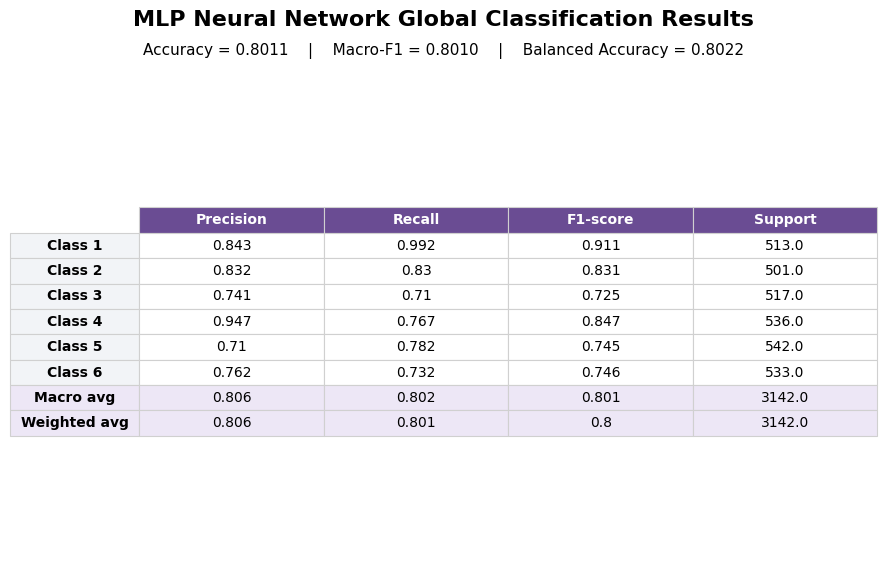

In [65]:
labels = [1, 2, 3, 4, 5, 6]
model_name = "MLP Neural Network"

mlp_accuracy = accuracy_score(y_test_true_mlp, y_test_pred_mlp)
mlp_macro_f1 = f1_score(y_test_true_mlp, y_test_pred_mlp, average="macro")
mlp_balanced_accuracy = balanced_accuracy_score(y_test_true_mlp, y_test_pred_mlp)

summary_metrics = {
    "Accuracy": mlp_accuracy,
    "Macro-F1": mlp_macro_f1,
    "Balanced Accuracy": mlp_balanced_accuracy
}


report_dict = classification_report(
    y_test_true_mlp,
    y_test_pred_mlp,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

report_df = report_df.loc[
    [str(i) for i in labels] + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

report_df["support"] = report_df["support"].astype(int)

display_df = report_df.copy()

display_df[["precision", "recall", "f1-score"]] = display_df[
    ["precision", "recall", "f1-score"]
].round(3)

display_df = display_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

display_df.index = [
    "Class 1", "Class 2", "Class 3",
    "Class 4", "Class 5", "Class 6",
    "Macro avg", "Weighted avg"
]

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.axis("off")

title = f"{model_name} Global Classification Results"

subtitle = (
    f"Accuracy = {summary_metrics['Accuracy']:.4f}    |    "
    f"Macro-F1 = {summary_metrics['Macro-F1']:.4f}    |    "
    f"Balanced Accuracy = {summary_metrics['Balanced Accuracy']:.4f}"
)

fig.text(
    0.5, 0.94,
    title,
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.89,
    subtitle,
    ha="center",
    fontsize=11
)

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_facecolor("#6A4C93")
        cell.set_text_props(color="white", weight="bold")

    if col == -1:
        cell.set_facecolor("#F2F4F7")
        cell.set_text_props(weight="bold")

    if row in [7, 8]:
        cell.set_facecolor("#EDE7F6")

plt.tight_layout(rect=[0, 0, 1, 0.86])

plt.show()

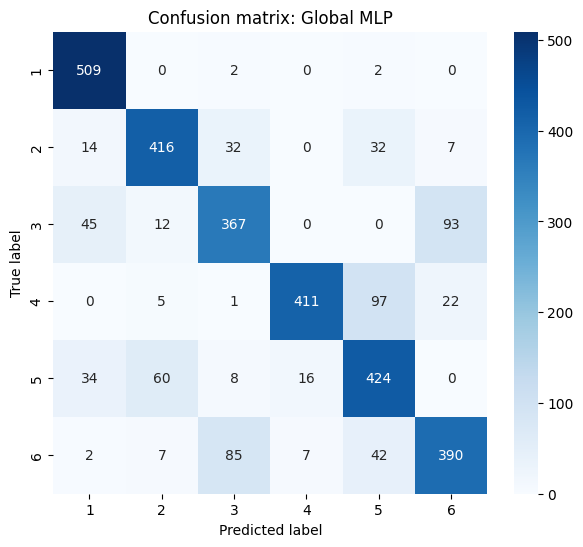

In [66]:
cm_mlp = confusion_matrix(
    y_test_true_mlp,
    y_test_pred_mlp,
    labels=[1, 2, 3, 4, 5, 6]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5, 6],
    yticklabels=[1, 2, 3, 4, 5, 6]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix: Global MLP")
plt.show()

### Выводы:
Для обучения в `PyTorch` исходные метки классов 1–6 были преобразованы в диапазон 0–5, так как функция потерь CrossEntropyLoss ожидает нумерацию классов с нуля. Признаки и метки были преобразованы в тензоры, после чего были сформированы DataLoader для обучающей, валидационной и тестовой выборок.

Архитектура MLP включала входной слой на 16 признаков, два скрытых слоя размерности 64 и 32, Batch Normalization, функцию активации ReLU и Dropout для регуляризации. Выходной слой содержал 6 нейронов, соответствующих шести жестам. Для оптимизации использовался Adam с learning rate 0.001 и weight decay 0.0001. Обучение проводилось с контролем качества на валидационной выборке и механизмом early stopping.

В процессе обучения MLP значение функции потерь постепенно снижалось, а качество на валидационной выборке росло. **На первых эпохах Macro-F1 увеличился с 0.6118 до значений выше 0.87, что говорит о том, что модель успешно изучала зависимость между признаками и классами жестов.** Максимальное качество на валидации было достигнуто примерно к 56-й эпохе, где Validation Macro-F1 составил около 0.8919. При отсутствии дальнейшего роста Macro-F1 сработал механизм early stopping, и для тестирования было восстановлено лучшее состояние модели по валидационной метрике.

На тестовой выборке MLP показала Accuracy = 0.8011, Macro-F1 = 0.8010 и Balanced Accuracy = 0.8022. **Эти результаты немного выше, чем у Random Forest, что делает MLP лучшей моделью среди подходов, использующих признаки MAV и MDF. При этом качество на валидационной выборке было выше, чем на тестовой, что указывает на сложность subject-independent EMG-классификации и различия между пользователями.**

### 1D-CNN

In [67]:
valid_labels = {1, 2, 3, 4, 5, 6}

fs = 1000
window_ms = 200
overlap = 0.5

window_size = int(fs * window_ms / 1000)
step = int(window_size * (1 - overlap))

print("window_size:", window_size)
print("step:", step)


def create_raw_windows_by_segment(
    df,
    channels,
    window_size=200,
    step=100,
    purity_threshold=0.9,
    min_segment_len_for_filtered=500
):
    X_raw = []
    y_raw = []
    subjects = []
    series_ids = []
    file_ids = []
    segment_ids = []

    for segment_id, group in tqdm(df.groupby("segment_id")):
        group = group.sort_values("time").reset_index(drop=True)

        if len(group) < max(window_size, min_segment_len_for_filtered):
            continue

        signal = group[channels].values.astype(np.float32)
        labels = group["label"].values.astype(int)

        subject = group["subject"].iloc[0]
        series = group["series"].iloc[0]
        file_id = group["file_id"].iloc[0]

        for start in range(0, len(group) - window_size + 1, step):
            end = start + window_size

            window_signal = signal[start:end]
            window_labels = labels[start:end]

            counts = np.bincount(window_labels)
            main_label = counts.argmax()
            purity = np.mean(window_labels == main_label)

            if main_label in valid_labels and purity >= purity_threshold:
                X_raw.append(window_signal)
                y_raw.append(main_label)
                subjects.append(subject)
                series_ids.append(series)
                file_ids.append(file_id)
                segment_ids.append(segment_id)

    return (
        np.array(X_raw, dtype=np.float32),
        np.array(y_raw, dtype=np.int64),
        np.array(subjects),
        np.array(series_ids),
        np.array(file_ids),
        np.array(segment_ids)
    )

window_size: 200
step: 100


In [68]:
X_raw, y_raw, subjects_raw, series_raw, file_ids_raw, segment_ids_raw = create_raw_windows_by_segment(
    data_filtered,
    channels=emg_channels,
    window_size=window_size,
    step=step,
    purity_threshold=0.9
)

print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)
print(pd.Series(y_raw).value_counts().sort_index())

print("Пользователей:", len(np.unique(subjects_raw)))
print("Файлов:", len(np.unique(file_ids_raw)))
print("Сегментов:", len(np.unique(segment_ids_raw)))

100%|██████████| 146/146 [00:01<00:00, 98.27it/s] 


X_raw: (13629, 200, 8)
y_raw: (13629,)
1    2264
2    2206
3    2268
4    2292
5    2292
6    2307
Name: count, dtype: int64
Пользователей: 36
Файлов: 72
Сегментов: 109


In [69]:
train_mask_raw = np.isin(subjects_raw, train_subjects)
val_mask_raw = np.isin(subjects_raw, val_subjects)
test_mask_raw = np.isin(subjects_raw, test_subjects)

X_train_raw = X_raw[train_mask_raw]
y_train_raw = y_raw[train_mask_raw]

X_val_raw = X_raw[val_mask_raw]
y_val_raw = y_raw[val_mask_raw]

X_test_raw = X_raw[test_mask_raw]
y_test_raw = y_raw[test_mask_raw]

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)

print("Train labels:")
print(pd.Series(y_train_raw).value_counts().sort_index())

print("Val labels:")
print(pd.Series(y_val_raw).value_counts().sort_index())

print("Test labels:")
print(pd.Series(y_test_raw).value_counts().sort_index())

X_train_raw: (7925, 200, 8)
X_val_raw: (2562, 200, 8)
X_test_raw: (3142, 200, 8)
Train labels:
1    1322
2    1278
3    1339
4    1330
5    1315
6    1341
Name: count, dtype: int64
Val labels:
1    429
2    427
3    412
4    426
5    435
6    433
Name: count, dtype: int64
Test labels:
1    513
2    501
3    517
4    536
5    542
6    533
Name: count, dtype: int64


In [70]:
train_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
train_std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_raw_norm = (X_train_raw - train_mean) / train_std
X_val_raw_norm = (X_val_raw - train_mean) / train_std
X_test_raw_norm = (X_test_raw - train_mean) / train_std

In [71]:
class EMGRawDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y - 1, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = EMGRawDataset(X_train_raw_norm, y_train_raw)
val_dataset = EMGRawDataset(X_val_raw_norm, y_val_raw)
test_dataset = EMGRawDataset(X_test_raw_norm, y_test_raw)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [72]:
class EMG1DCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=8, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

cnn_model = EMG1DCNN(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Device: cpu


In [74]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def predict_model(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

In [75]:
num_epochs = 80
patience = 12

best_val_f1 = 0
best_state = None
patience_counter = 0

history_cnn = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        cnn_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    y_val_true, y_val_pred = predict_model(
        cnn_model,
        val_loader,
        device
    )

    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_f1 = f1_score(y_val_true, y_val_pred, average="macro")
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)

    history_cnn.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "val_balanced_accuracy": val_bal_acc
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(cnn_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

cnn_model.load_state_dict(best_state)

history_cnn_df = pd.DataFrame(history_cnn)
history_cnn_df.tail()

Epoch 001 | Loss: 1.0422 | Val Acc: 0.7884 | Val Macro-F1: 0.7861
Epoch 002 | Loss: 0.5041 | Val Acc: 0.8435 | Val Macro-F1: 0.8416
Epoch 003 | Loss: 0.4310 | Val Acc: 0.8571 | Val Macro-F1: 0.8553
Epoch 004 | Loss: 0.3890 | Val Acc: 0.8076 | Val Macro-F1: 0.8025
Epoch 005 | Loss: 0.3596 | Val Acc: 0.8618 | Val Macro-F1: 0.8614
Epoch 006 | Loss: 0.3414 | Val Acc: 0.8294 | Val Macro-F1: 0.8268
Epoch 007 | Loss: 0.3273 | Val Acc: 0.8294 | Val Macro-F1: 0.8276
Epoch 008 | Loss: 0.2919 | Val Acc: 0.8489 | Val Macro-F1: 0.8485
Epoch 009 | Loss: 0.2893 | Val Acc: 0.8165 | Val Macro-F1: 0.8135
Epoch 010 | Loss: 0.2776 | Val Acc: 0.8130 | Val Macro-F1: 0.8101
Epoch 011 | Loss: 0.2761 | Val Acc: 0.8649 | Val Macro-F1: 0.8639
Epoch 012 | Loss: 0.2554 | Val Acc: 0.8212 | Val Macro-F1: 0.8201
Epoch 013 | Loss: 0.2383 | Val Acc: 0.8310 | Val Macro-F1: 0.8290
Epoch 014 | Loss: 0.2398 | Val Acc: 0.8724 | Val Macro-F1: 0.8705
Epoch 015 | Loss: 0.2285 | Val Acc: 0.8618 | Val Macro-F1: 0.8602
Epoch 016 

,epoch,train_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
21,22,0.172324,0.797424,0.792312,0.794463
22,23,0.197438,0.867291,0.865723,0.866645
23,24,0.189646,0.849336,0.848118,0.849195
24,25,0.172259,0.837237,0.836475,0.835906
25,26,0.168445,0.836846,0.835891,0.835104


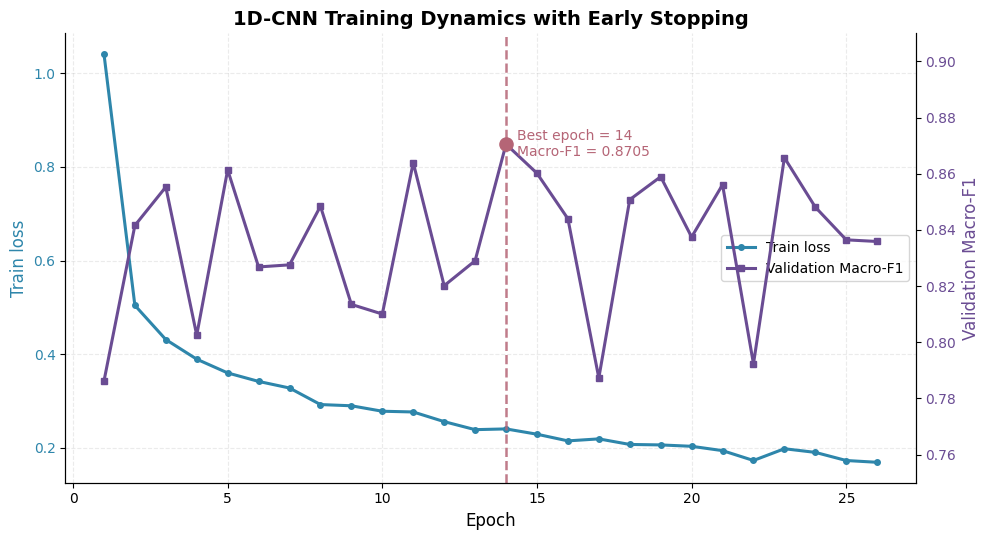

In [76]:
best_idx = history_cnn_df["val_macro_f1"].idxmax()
best_epoch = int(history_cnn_df.loc[best_idx, "epoch"])
best_f1 = history_cnn_df.loc[best_idx, "val_macro_f1"]

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.plot(
    history_cnn_df["epoch"],
    history_cnn_df["train_loss"],
    color="#2E86AB",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Train loss"
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Train loss", fontsize=12, color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")
ax1.grid(alpha=0.25, linestyle="--")

ax2 = ax1.twinx()

ax2.plot(
    history_cnn_df["epoch"],
    history_cnn_df["val_macro_f1"],
    color="#6A4C93",
    linewidth=2.2,
    marker="s",
    markersize=4,
    label="Validation Macro-F1"
)

ax2.set_ylabel("Validation Macro-F1", fontsize=12, color="#6A4C93")
ax2.tick_params(axis="y", labelcolor="#6A4C93")
ax2.set_ylim(0.75, 0.91)

ax1.axvline(
    best_epoch,
    color="#B56576",
    linestyle="--",
    linewidth=1.8,
    alpha=0.85
)

ax2.scatter(
    best_epoch,
    best_f1,
    color="#B56576",
    s=90,
    zorder=5
)

ax2.text(
    best_epoch + 0.35,
    best_f1,
    f"Best epoch = {best_epoch}\nMacro-F1 = {best_f1:.4f}",
    fontsize=10,
    color="#B56576",
    va="center"
)

plt.title(
    "1D-CNN Training Dynamics with Early Stopping",
    fontsize=14,
    fontweight="bold"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center right",
    frameon=True
)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()


plt.show()

In [77]:
y_test_true_nn, y_test_pred_nn = predict_model(
    cnn_model,
    test_loader,
    device
)

y_test_true_cnn = y_test_true_nn + 1
y_test_pred_cnn = y_test_pred_nn + 1

cnn_accuracy = accuracy_score(y_test_true_cnn, y_test_pred_cnn)
cnn_macro_f1 = f1_score(y_test_true_cnn, y_test_pred_cnn, average="macro")
cnn_balanced_accuracy = balanced_accuracy_score(y_test_true_cnn, y_test_pred_cnn)

print("Global 1D-CNN Raw EMG Results")
print("Accuracy:", cnn_accuracy)
print("Macro-F1:", cnn_macro_f1)
print("Balanced Accuracy:", cnn_balanced_accuracy)

Global 1D-CNN Raw EMG Results
Accuracy: 0.8087205601527689
Macro-F1: 0.8084715363667065
Balanced Accuracy: 0.8093918023798504


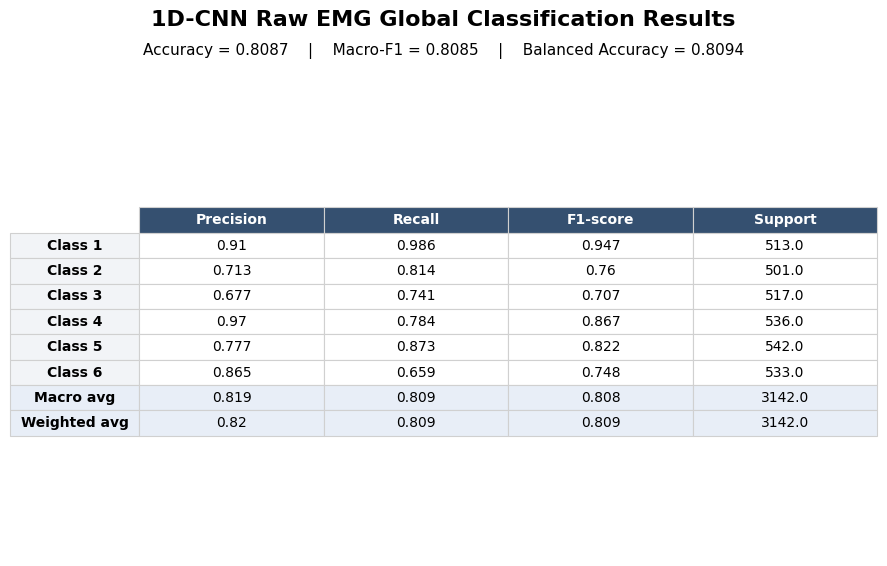

In [78]:
labels = [1, 2, 3, 4, 5, 6]
model_name = "1D-CNN Raw EMG"

cnn_accuracy = accuracy_score(y_test_true_cnn, y_test_pred_cnn)
cnn_macro_f1 = f1_score(y_test_true_cnn, y_test_pred_cnn, average="macro")
cnn_balanced_accuracy = balanced_accuracy_score(y_test_true_cnn, y_test_pred_cnn)

summary_metrics = {
    "Accuracy": cnn_accuracy,
    "Macro-F1": cnn_macro_f1,
    "Balanced Accuracy": cnn_balanced_accuracy
}

report_dict = classification_report(
    y_test_true_cnn,
    y_test_pred_cnn,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

report_df = report_df.loc[
    [str(i) for i in labels] + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

report_df["support"] = report_df["support"].astype(int)

display_df = report_df.copy()

display_df[["precision", "recall", "f1-score"]] = display_df[
    ["precision", "recall", "f1-score"]
].round(3)

display_df = display_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

display_df.index = [
    "Class 1", "Class 2", "Class 3",
    "Class 4", "Class 5", "Class 6",
    "Macro avg", "Weighted avg"
]
fig, ax = plt.subplots(figsize=(9, 5.8))
ax.axis("off")

title = f"{model_name} Global Classification Results"

subtitle = (
    f"Accuracy = {summary_metrics['Accuracy']:.4f}    |    "
    f"Macro-F1 = {summary_metrics['Macro-F1']:.4f}    |    "
    f"Balanced Accuracy = {summary_metrics['Balanced Accuracy']:.4f}"
)

fig.text(
    0.5, 0.94,
    title,
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.89,
    subtitle,
    ha="center",
    fontsize=11
)

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_facecolor("#355070")  # тёмно-синий для CNN
        cell.set_text_props(color="white", weight="bold")

    if col == -1:
        cell.set_facecolor("#F2F4F7")
        cell.set_text_props(weight="bold")

    if row in [7, 8]:
        cell.set_facecolor("#E8EEF7")

plt.tight_layout(rect=[0, 0, 1, 0.86])

plt.show()

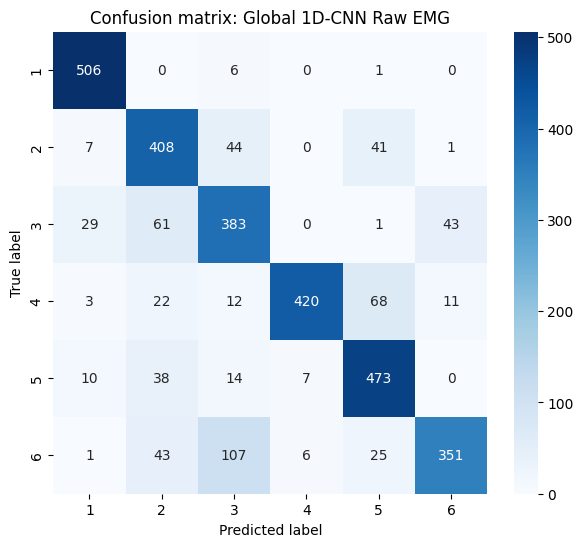

In [79]:
cm_cnn = confusion_matrix(
    y_test_true_cnn,
    y_test_pred_cnn,
    labels=[1, 2, 3, 4, 5, 6]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5, 6],
    yticklabels=[1, 2, 3, 4, 5, 6]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix: Global 1D-CNN Raw EMG")
plt.show()

In [80]:
final_global_results = pd.DataFrame([
    {
        "scenario": "global",
        "model": "Logistic Regression",
        "features": "MAV+MDF_8ch",
        "accuracy": logreg_accuracy,
        "macro_f1": logreg_macro_f1,
        "balanced_accuracy": logreg_balanced_accuracy
    },
    {
        "scenario": "global",
        "model": "Random Forest",
        "features": "MAV+MDF_8ch",
        "accuracy": rf_accuracy,
        "macro_f1": rf_macro_f1,
        "balanced_accuracy": rf_balanced_accuracy
    },
    {
        "scenario": "global",
        "model": "MLP Neural Network",
        "features": "MAV+MDF_8ch",
        "accuracy": mlp_accuracy,
        "macro_f1": mlp_macro_f1,
        "balanced_accuracy": mlp_balanced_accuracy
    },
    {
        "scenario": "global",
        "model": "1D-CNN",
        "features": "Raw_EMG_200x8",
        "accuracy": cnn_accuracy,
        "macro_f1": cnn_macro_f1,
        "balanced_accuracy": cnn_balanced_accuracy
    }
])

final_global_results = final_global_results.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

In [ ]:
styled_final_global_results = (
    final_global_results.style
    .format({
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "balanced_accuracy": "{:.4f}"
    })
    .set_caption("Final Global Model Benchmark")
    .background_gradient(
        cmap="Blues",
        subset=["accuracy", "macro_f1", "balanced_accuracy"]
    )
    .highlight_max(
        subset=["accuracy", "macro_f1", "balanced_accuracy"],
        color="#49bf45"
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("color", "#222"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
)

styled_final_global_results

,scenario,model,features,accuracy,macro_f1,balanced_accuracy
0,global,1D-CNN,Raw_EMG_200x8,0.8087,0.8085,0.8094
1,global,MLP Neural Network,MAV+MDF_8ch,0.8011,0.8010,0.8022
2,global,Random Forest,MAV+MDF_8ch,0.7973,0.7979,0.7983
3,global,Logistic Regression,MAV+MDF_8ch,0.7836,0.7830,0.7844


### Выводы:

После обучения моделей на признаках MAV и MDF был проведён дополнительный эксперимент с использованием сырых временных окон EMG-сигнала. Цель данного этапа заключалась в проверке того, может ли нейронная сеть автоматически извлечь более информативные временные признаки из исходной формы сигнала, не ограничиваясь заранее рассчитанными ручными признаками.

Для этого отфильтрованный EMG-сигнал был повторно разбит на окна длительностью 200 мс с перекрытием 50%. При частоте дискретизации 1000 Гц каждое окно содержало 200 временных отсчётов. Поскольку использовались восемь EMG-каналов, форма одного окна составила 200×8. В отличие от предыдущего этапа Feature Engineering, где каждое окно преобразовывалось в 16 признаков MAV и MDF, в данном эксперименте временная структура окна сохранялась полностью.

Оконное разбиение выполнялось внутри непрерывных временных сегментов `segment_id`, что исключало попадание в одно окно фрагментов, разделённых временными разрывами. Для каждого окна определялась доминирующая метка класса. В выборку включались только окна с целевыми метками 1–6 и чистотой метки не менее 90%. В результате был сформирован массив `X_raw` размером 13629×200×8 и массив меток `y_raw` размером 13629. Распределение классов осталось близким к сбалансированному, а количество окон совпало с количеством окон, использованных для MAV/MDF-признаков.

Далее данные были разделены на обучающую, валидационную и тестовую выборки по тем же пользователям, что и в предыдущих экспериментах. Это позволило сохранить subject-independent сценарий оценки и сравнивать 1D-CNN с Logistic Regression, Random Forest и MLP в одинаковых условиях. Размер обучающей выборки составил 7925 окон, валидационной — 2562 окна, тестовой — 3142 окна.

Перед обучением была выполнена нормализация сырых окон EMG-сигнала. Среднее значение и стандартное отклонение рассчитывались только на обучающей выборке отдельно для каждого EMG-канала. Затем эти параметры применялись к обучающей, валидационной и тестовой выборкам. Такой подход позволил привести каналы к сопоставимому масштабу и избежать утечки информации из тестовых данных.

Для классификации была использована одномерная сверточная нейронная сеть 1D-CNN. Вход модели имел форму 8×200, где 8 соответствует количеству EMG-каналов, а 200 — длине временного окна. Перед подачей в сеть данные были преобразованы из формата `N×200×8` в формат `N×8×200`, поскольку слой `Conv1d` в PyTorch ожидает вход в формате “batch size — channels — sequence length”. Метки классов были преобразованы из диапазона 1–6 в диапазон 0–5, что требуется для функции потерь `CrossEntropyLoss`.

**Архитектура 1D-CNN включала несколько сверточных блоков с Batch Normalization, функцией активации ReLU и MaxPooling.** Сверточные слои позволяли модели извлекать локальные временные паттерны EMG-сигнала, включая кратковременные изменения амплитуды и совместную активность каналов. После сверточной части использовался `AdaptiveAvgPool1d`, который преобразовывал временную карту признаков в компактное представление. Далее классификатор на полносвязных слоях выдавал вероятности принадлежности окна к одному из шести жестов.

Обучение выполнялось с использованием оптимизатора Adam, функции потерь CrossEntropyLoss и механизма early stopping по значению Macro-F1 на валидационной выборке. На первых эпохах качество модели быстро увеличивалось: к третьей эпохе Validation Macro-F1 достигло примерно 0.855, а максимальное значение на валидационной выборке составило около 0.871.

На тестовой выборке 1D-CNN показала Accuracy 0.8087, Macro-F1 0.8085 и Balanced Accuracy 0.8094. Эти значения оказались **немного выше**, чем у других моделей.

## 7.Bootstrap CI

Для оценки устойчивости результатов были рассчитаны 95% доверительные интервалы метрик Accuracy, Macro-F1 и Balanced Accuracy с использованием bootstrap по test-пользователям.

Bootstrap показал, что 1D-CNN имеет наилучшее среднее значение Macro-F1, однако доверительные интервалы сильных восьмиканальных моделей частично пересекаются.

**В качестве основной метрики использовалась Macro-F1, поскольку задача является многоклассовой, а для управления бионическим протезом важно устойчивое распознавание каждого жеста. Accuracy применялась как общая метрика качества, Balanced Accuracy — как дополнительная проверка устойчивости по классам. AUC не использовалась как основная метрика, так как в многоклассовой EMG-классификации она менее наглядна для анализа ошибок между конкретными жестами, чем Macro-F1 и матрица ошибок.**

In [82]:
LABELS = [1, 2, 3, 4, 5, 6]


def compute_metrics(y_true, y_pred, labels=LABELS):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": recall_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0
        )
    }


def bootstrap_ci_by_subject(
    y_true,
    y_pred,
    subject_ids,
    n_bootstrap=1000,
    ci=95,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    subject_ids = np.array(subject_ids)

    assert len(y_true) == len(y_pred) == len(subject_ids)

    unique_subjects = np.unique(subject_ids)

    subject_to_indices = {
        subject: np.where(subject_ids == subject)[0]
        for subject in unique_subjects
    }

    bootstrap_results = {
        "accuracy": [],
        "macro_f1": [],
        "balanced_accuracy": []
    }

    for _ in range(n_bootstrap):
        sampled_subjects = rng.choice(
            unique_subjects,
            size=len(unique_subjects),
            replace=True
        )

        sampled_indices = np.concatenate([
            subject_to_indices[subj]
            for subj in sampled_subjects
        ])

        metrics = compute_metrics(
            y_true[sampled_indices],
            y_pred[sampled_indices]
        )

        for metric_name in bootstrap_results:
            bootstrap_results[metric_name].append(metrics[metric_name])

    rows = []
    alpha = (100 - ci) / 2

    for metric_name, values in bootstrap_results.items():
        values = np.array(values)

        rows.append({
            "metric": metric_name,
            "mean": values.mean(),
            "ci_lower": np.percentile(values, alpha),
            "ci_upper": np.percentile(values, 100 - alpha)
        })

    return pd.DataFrame(rows)

In [83]:
test_subject_ids_mav_mdf = subjects_mav_mdf[test_mask]

In [84]:
test_subject_ids_raw = subjects_raw[test_mask_raw]

In [85]:
print(len(y_test), len(test_subject_ids_mav_mdf))
print(len(y_test_true_cnn), len(test_subject_ids_raw))

3142 3142
3142 3142


In [86]:
bootstrap_inputs = [
    {
        "model": "Logistic Regression",
        "features": "MAV+MDF_8ch",
        "y_true": y_test,
        "y_pred": y_pred_logreg,
        "subjects": test_subject_ids_mav_mdf
    },
    {
        "model": "Random Forest",
        "features": "MAV+MDF_8ch",
        "y_true": y_test,
        "y_pred": y_pred_rf,
        "subjects": test_subject_ids_mav_mdf
    },
    {
        "model": "MLP Neural Network",
        "features": "MAV+MDF_8ch",
        "y_true": y_test_true_mlp,
        "y_pred": y_test_pred_mlp,
        "subjects": test_subject_ids_mav_mdf
    },
    {
        "model": "1D-CNN",
        "features": "Raw_EMG_200x8",
        "y_true": y_test_true_cnn,
        "y_pred": y_test_pred_cnn,
        "subjects": test_subject_ids_raw
    }
]

In [87]:
all_ci_results = []

for item in bootstrap_inputs:
    ci_df = bootstrap_ci_by_subject(
        y_true=item["y_true"],
        y_pred=item["y_pred"],
        subject_ids=item["subjects"],
        n_bootstrap=1000,
        ci=95,
        random_state=42
    )

    ci_df["model"] = item["model"]
    ci_df["features"] = item["features"]

    all_ci_results.append(ci_df)

bootstrap_ci_results = pd.concat(all_ci_results, ignore_index=True)

bootstrap_ci_results = bootstrap_ci_results[
    ["model", "features", "metric", "mean", "ci_lower", "ci_upper"]
]

bootstrap_ci_results.round(4)

,model,features,metric,mean,ci_lower,ci_upper
0,Logistic Regression,MAV+MDF_8ch,accuracy,0.7819,0.6519,0.8828
1,Logistic Regression,MAV+MDF_8ch,macro_f1,0.7809,0.6521,0.8822
2,Logistic Regression,MAV+MDF_8ch,balanced_accuracy,0.7830,0.6524,0.8845
3,Random Forest,MAV+MDF_8ch,accuracy,0.7943,0.6687,0.8889
4,Random Forest,MAV+MDF_8ch,macro_f1,0.7953,0.6736,0.8893
5,Random Forest,MAV+MDF_8ch,balanced_accuracy,0.7955,0.6706,0.8905
6,MLP Neural Network,MAV+MDF_8ch,accuracy,0.7976,0.6666,0.8995
7,MLP Neural Network,MAV+MDF_8ch,macro_f1,0.7973,0.6647,0.9008
8,MLP Neural Network,MAV+MDF_8ch,balanced_accuracy,0.7986,0.6671,0.9005
9,1D-CNN,Raw_EMG_200x8,accuracy,0.8065,0.6716,0.8979


In [88]:
macro_f1_ci = bootstrap_ci_results[
    bootstrap_ci_results["metric"] == "macro_f1"
].copy()

macro_f1_ci = macro_f1_ci.sort_values(
    by="mean",
    ascending=False
).reset_index(drop=True)

macro_f1_ci.round(4)

,model,features,metric,mean,ci_lower,ci_upper
0,1D-CNN,Raw_EMG_200x8,macro_f1,0.8059,0.6723,0.8976
1,MLP Neural Network,MAV+MDF_8ch,macro_f1,0.7973,0.6647,0.9008
2,Random Forest,MAV+MDF_8ch,macro_f1,0.7953,0.6736,0.8893
3,Logistic Regression,MAV+MDF_8ch,macro_f1,0.7809,0.6521,0.8822


In [89]:
bootstrap_ci_results["mean_ci"] = (
    bootstrap_ci_results["mean"].round(4).astype(str)
    + " ["
    + bootstrap_ci_results["ci_lower"].round(4).astype(str)
    + "; "
    + bootstrap_ci_results["ci_upper"].round(4).astype(str)
    + "]"
)

ci_report_table = bootstrap_ci_results.pivot_table(
    index=["model", "features"],
    columns="metric",
    values="mean_ci",
    aggfunc="first"
).reset_index()

ci_report_table = ci_report_table.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

ci_report_table

metric,model,features,accuracy,balanced_accuracy,macro_f1
0,1D-CNN,Raw_EMG_200x8,0.8065 [0.6716; 0.8979],0.8073 [0.6728; 0.898],0.8059 [0.6723; 0.8976]
1,MLP Neural Network,MAV+MDF_8ch,0.7976 [0.6666; 0.8995],0.7986 [0.6671; 0.9005],0.7973 [0.6647; 0.9008]
2,Random Forest,MAV+MDF_8ch,0.7943 [0.6687; 0.8889],0.7955 [0.6706; 0.8905],0.7953 [0.6736; 0.8893]
3,Logistic Regression,MAV+MDF_8ch,0.7819 [0.6519; 0.8828],0.783 [0.6524; 0.8845],0.7809 [0.6521; 0.8822]


### Выводы:

На каждой bootstrap-итерации из набора тестовых пользователей случайно выбирались пользователи с возвращением, после чего для выбранных пользователей объединялись все соответствующие окна. На полученной выборке рассчитывались Accuracy, Macro-F1 и Balanced Accuracy. Процедура повторялась 1000 раз, после чего для каждой метрики оценивались среднее значение и 95% доверительный интервал.

**В bootstrap были включены четыре глобальные модели: Logistic Regression, Random Forest, MLP Neural Network и 1D-CNN.**

По среднему значению Macro-F1 лучший результат показала 1D-CNN. Её Macro-F1 составил около 0.806 с 95% доверительным интервалом примерно от 0.679 до 0.893. Random Forest показал близкий результат: средний Macro-F1 около 0.795 с доверительным интервалом от 0.674 до 0.889. MLP Neural Network и Logistic Regression также продемонстрировали сопоставимые значения, но их средние результаты были немного ниже.

## 8.Персональная модель

Для каждого test-пользователя из первой серии выбиралось k окон на каждый класс, где k принимало значения 5, 10, 20 и 40. Эти окна использовались для обучения персональной модели, тестирование выполнялось на второй серии этого же пользователя.

В персональных моделях были протестированы Logistic Regression, Random Forest и KNN - эти модели выбраны потому, что персональная выборка имеет небольшой размер, и классические алгоритмы часто устойчивее нейросетей при малом числе обучающих примеров.

Результаты показали, что качество персональных моделей возрастает с увеличением числа калибровочных окон.

In [90]:
def take_k_per_class(indices, y_all, k=20, random_state=42):
    rng = np.random.default_rng(random_state)
    selected = []

    for cls in sorted(np.unique(y_all[indices])):
        cls_indices = indices[y_all[indices] == cls]
        cls_indices = rng.permutation(cls_indices)

        n_take = min(k, len(cls_indices))
        selected.extend(cls_indices[:n_take])

    return np.array(selected)

In [91]:
def predict_global_mlp(model, X_scaled, device):
    model.eval()

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model(X_tensor)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    return preds + 1

In [92]:
def run_personal_benchmark_mav_mdf(k_per_class=20, random_state=42):
    rows = []

    all_true = []

    all_pred_personal_lr = []
    all_pred_personal_rf = []
    all_pred_personal_knn = []

    all_pred_global_lr = []
    all_pred_global_rf = []
    all_pred_global_mlp = []

    subjects_array = np.array(subjects_mav_mdf).astype(str)
    series_array = np.array(series_mav_mdf).astype(str)

    for subject in test_subjects:
        subject_mask = subjects_array == subject

        calibration_pool = np.where(
            subject_mask & (series_array == "1")
        )[0]

        test_indices = np.where(
            subject_mask & (series_array == "2")
        )[0]

        if len(calibration_pool) == 0 or len(test_indices) == 0:
            print("Skip subject:", subject)
            continue

        calibration_indices = take_k_per_class(
            calibration_pool,
            y_mav_mdf,
            k=k_per_class,
            random_state=random_state
        )

        X_cal = X_mav_mdf[calibration_indices]
        y_cal = y_mav_mdf[calibration_indices]

        X_sub_test = X_mav_mdf[test_indices]
        y_sub_test = y_mav_mdf[test_indices]

        cal_classes = sorted(np.unique(y_cal))
        test_classes = sorted(np.unique(y_sub_test))

        personal_scaler = StandardScaler()
        X_cal_scaled = personal_scaler.fit_transform(X_cal)
        X_sub_test_scaled_personal = personal_scaler.transform(X_sub_test)

        personal_lr = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=random_state
        )

        personal_lr.fit(X_cal_scaled, y_cal)
        y_pred_personal_lr = personal_lr.predict(X_sub_test_scaled_personal)

        personal_rf = RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        )

        personal_rf.fit(X_cal, y_cal)
        y_pred_personal_rf = personal_rf.predict(X_sub_test)

        n_neighbors = min(3, len(X_cal_scaled))

        personal_knn = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights="distance",
            metric="euclidean"
        )

        personal_knn.fit(X_cal_scaled, y_cal)
        y_pred_personal_knn = personal_knn.predict(X_sub_test_scaled_personal)

        X_sub_test_scaled_global = scaler.transform(X_sub_test)

        y_pred_global_lr = logreg.predict(X_sub_test_scaled_global)
        y_pred_global_rf = rf.predict(X_sub_test)


        y_pred_global_mlp = predict_global_mlp(
            mlp_model,
            X_sub_test_scaled_global,
            device
        )

        rows.append({
            "subject": subject,
            "k_per_class": k_per_class,
            "n_calibration": len(calibration_indices),
            "n_test": len(test_indices),
            "calibration_classes": str(cal_classes),
            "test_classes": str(test_classes),

            "personal_lr_accuracy": accuracy_score(y_sub_test, y_pred_personal_lr),
            "personal_lr_macro_f1": f1_score(y_sub_test, y_pred_personal_lr, average="macro"),
            "personal_lr_balanced_accuracy": balanced_accuracy_score(y_sub_test, y_pred_personal_lr),

            "personal_rf_accuracy": accuracy_score(y_sub_test, y_pred_personal_rf),
            "personal_rf_macro_f1": f1_score(y_sub_test, y_pred_personal_rf, average="macro"),
            "personal_rf_balanced_accuracy": balanced_accuracy_score(y_sub_test, y_pred_personal_rf),

            "personal_knn_accuracy": accuracy_score(y_sub_test, y_pred_personal_knn),
            "personal_knn_macro_f1": f1_score(y_sub_test, y_pred_personal_knn, average="macro"),
            "personal_knn_balanced_accuracy": balanced_accuracy_score(y_sub_test, y_pred_personal_knn),

            "global_lr_accuracy": accuracy_score(y_sub_test, y_pred_global_lr),
            "global_lr_macro_f1": f1_score(y_sub_test, y_pred_global_lr, average="macro"),

            "global_rf_accuracy": accuracy_score(y_sub_test, y_pred_global_rf),
            "global_rf_macro_f1": f1_score(y_sub_test, y_pred_global_rf, average="macro"),

            "global_mlp_accuracy": accuracy_score(y_sub_test, y_pred_global_mlp),
            "global_mlp_macro_f1": f1_score(y_sub_test, y_pred_global_mlp, average="macro"),
        })

        all_true.extend(y_sub_test)

        all_pred_personal_lr.extend(y_pred_personal_lr)
        all_pred_personal_rf.extend(y_pred_personal_rf)
        all_pred_personal_knn.extend(y_pred_personal_knn)

        all_pred_global_lr.extend(y_pred_global_lr)
        all_pred_global_rf.extend(y_pred_global_rf)
        all_pred_global_mlp.extend(y_pred_global_mlp)

    all_true = np.array(all_true)

    summary = pd.DataFrame([
        {
            "scenario": f"personal_series1_to_series2_k{k_per_class}",
            "model": "Personal Logistic Regression",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_personal_lr),
            "macro_f1": f1_score(all_true, all_pred_personal_lr, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_personal_lr)
        },
        {
            "scenario": f"personal_series1_to_series2_k{k_per_class}",
            "model": "Personal Random Forest",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_personal_rf),
            "macro_f1": f1_score(all_true, all_pred_personal_rf, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_personal_rf)
        },
        {
            "scenario": f"personal_series1_to_series2_k{k_per_class}",
            "model": "Personal KNN",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_personal_knn),
            "macro_f1": f1_score(all_true, all_pred_personal_knn, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_personal_knn)
        },
        {
            "scenario": f"same_series2_windows_k{k_per_class}",
            "model": "Global Logistic Regression",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_global_lr),
            "macro_f1": f1_score(all_true, all_pred_global_lr, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_global_lr)
        },
        {
            "scenario": f"same_series2_windows_k{k_per_class}",
            "model": "Global Random Forest",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_global_rf),
            "macro_f1": f1_score(all_true, all_pred_global_rf, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_global_rf)
        },
        {
            "scenario": f"same_series2_windows_k{k_per_class}",
            "model": "Global MLP Neural Network",
            "features": "MAV+MDF_8ch",
            "accuracy": accuracy_score(all_true, all_pred_global_mlp),
            "macro_f1": f1_score(all_true, all_pred_global_mlp, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(all_true, all_pred_global_mlp)
        }
    ])

    per_subject = pd.DataFrame(rows)

    return summary, per_subject

### функция запускает для каждого пользователя из `test_subjects`:

1. Берёт series 1 как calibration_pool
2. Берёт series 2 как test_indices
3. Из series 1 выбирает k окон каждого класса
4. Обучает персональные модели:
   - Personal Logistic Regression
   - Personal Random Forest
   - Personal KNN
5. Проверяет их на series 2 этого же пользователя
6. Параллельно проверяет глобальные модели на тех же series 2 окнах
7. Сохраняет результаты по каждому пользователю и общий summary

In [93]:
all_personal_summaries = []
all_personal_per_subject = []

for k in [5, 10, 20, 40]:
    summary_k, per_subject_k = run_personal_benchmark_mav_mdf(
        k_per_class=k,
        random_state=42
    )

    all_personal_summaries.append(summary_k)

    per_subject_k["k_per_class"] = k
    all_personal_per_subject.append(per_subject_k)

personal_comparison = pd.concat(all_personal_summaries, ignore_index=True)
personal_per_subject_all = pd.concat(all_personal_per_subject, ignore_index=True)

personal_comparison.sort_values(
    by=["scenario", "macro_f1"],
    ascending=[True, False]
).round(4)

,scenario,model,features,accuracy,macro_f1,balanced_accuracy
7,personal_series1_to_series2_k10,Personal Random Forest,MAV+MDF_8ch,0.8790,0.8798,0.8820
6,personal_series1_to_series2_k10,Personal Logistic Regression,MAV+MDF_8ch,0.8488,0.8484,0.8496
8,personal_series1_to_series2_k10,Personal KNN,MAV+MDF_8ch,0.7517,0.7516,0.7534
13,personal_series1_to_series2_k20,Personal Random Forest,MAV+MDF_8ch,0.8973,0.8982,0.9002
12,personal_series1_to_series2_k20,Personal Logistic Regression,MAV+MDF_8ch,0.8922,0.8927,0.8937
14,personal_series1_to_series2_k20,Personal KNN,MAV+MDF_8ch,0.7965,0.7965,0.7979
18,personal_series1_to_series2_k40,Personal Logistic Regression,MAV+MDF_8ch,0.9118,0.9120,0.9133
19,personal_series1_to_series2_k40,Personal Random Forest,MAV+MDF_8ch,0.9023,0.9027,0.9050
20,personal_series1_to_series2_k40,Personal KNN,MAV+MDF_8ch,0.8173,0.8177,0.8184
1,personal_series1_to_series2_k5,Personal Random Forest,MAV+MDF_8ch,0.8481,0.8479,0.8507


In [94]:
personal_only = personal_comparison[
    personal_comparison["model"].str.contains("Personal")
].copy()

personal_only["k"] = personal_only["scenario"].str.extract(r"k(\d+)").astype(int)

personal_only = personal_only.sort_values(
    by=["k", "macro_f1"],
    ascending=[True, False]
)

personal_only[[
    "k", "model", "features", "accuracy", "macro_f1", "balanced_accuracy"
]].round(4)

,k,model,features,accuracy,macro_f1,balanced_accuracy
1,5,Personal Random Forest,MAV+MDF_8ch,0.8481,0.8479,0.8507
0,5,Personal Logistic Regression,MAV+MDF_8ch,0.7631,0.7641,0.7664
2,5,Personal KNN,MAV+MDF_8ch,0.7013,0.7002,0.7031
7,10,Personal Random Forest,MAV+MDF_8ch,0.8790,0.8798,0.8820
6,10,Personal Logistic Regression,MAV+MDF_8ch,0.8488,0.8484,0.8496
8,10,Personal KNN,MAV+MDF_8ch,0.7517,0.7516,0.7534
13,20,Personal Random Forest,MAV+MDF_8ch,0.8973,0.8982,0.9002
12,20,Personal Logistic Regression,MAV+MDF_8ch,0.8922,0.8927,0.8937
14,20,Personal KNN,MAV+MDF_8ch,0.7965,0.7965,0.7979
18,40,Personal Logistic Regression,MAV+MDF_8ch,0.9118,0.9120,0.9133


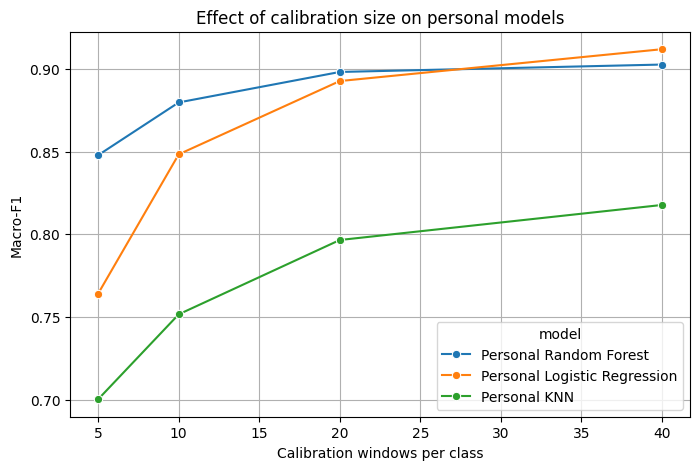

In [95]:
personal_plot_df = personal_only.copy()

personal_plot_df["k"] = personal_plot_df["scenario"].str.extract(r"k(\d+)").astype(int)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=personal_plot_df,
    x="k",
    y="macro_f1",
    hue="model",
    marker="o"
)

plt.xlabel("Calibration windows per class")
plt.ylabel("Macro-F1")
plt.title("Effect of calibration size on personal models")
plt.grid(True)
plt.show()

### Выводы:

После оценки глобальных моделей был проведён дополнительный эксперимент с персональными моделями. В данном эксперименте использовались только тестовые пользователи. Для каждого из них данные первой серии рассматривались как калибровочная выборка, а данные второй серии — как тестовая выборка.

Из калибровочной серии для каждого пользователя выбиралось фиксированное количество окон на каждый класс. Были рассмотрены значения k = 5, 10, 20 и 40, где k обозначает число калибровочных окон на один жест. Поскольку в задаче использовалось шесть целевых жестов, при k = 20 персональная модель обучалась примерно на 120 окнах пользователя.

Результаты показали, что персональная калибровка существенно повышает качество классификации. **Даже при k = 5 лучшая персональная модель достигла Macro-F1 около 0.848, что выше качества глобальных моделей на тех же тестовых пользователях.** **При увеличении количества калибровочных окон качество последовательно возрастало: при k = 10 Macro-F1 составил около 0.880, при k = 20 — около 0.898, а при k = 40 — около 0.912.**

Наиболее устойчивые результаты показали Personal Random Forest и Personal Logistic Regression. Random Forest оказался лучшим при k = 5, 10 и 20, тогда как при k = 40 наилучший результат показала Logistic Regression. Personal KNN показал более низкое качество, что указывает на его большую чувствительность к небольшому объёму.


## 9.Сравниваем модели


In [96]:
final_global_results = pd.DataFrame([
    {
        "scenario": "global_subject_independent",
        "model": "Logistic Regression",
        "features": "MAV+MDF_8ch",
        "accuracy": logreg_accuracy,
        "macro_f1": logreg_macro_f1,
        "balanced_accuracy": logreg_balanced_accuracy
    },
    {
        "scenario": "global_subject_independent",
        "model": "Random Forest",
        "features": "MAV+MDF_8ch",
        "accuracy": rf_accuracy,
        "macro_f1": rf_macro_f1,
        "balanced_accuracy": rf_balanced_accuracy
    },
    {
        "scenario": "global_subject_independent",
        "model": "MLP Neural Network",
        "features": "MAV+MDF_8ch",
        "accuracy": mlp_accuracy,
        "macro_f1": mlp_macro_f1,
        "balanced_accuracy": mlp_balanced_accuracy
    },
    {
        "scenario": "global_subject_independent",
        "model": "1D-CNN",
        "features": "Raw_EMG_200x8",
        "accuracy": cnn_accuracy,
        "macro_f1": cnn_macro_f1,
        "balanced_accuracy": cnn_balanced_accuracy
    }
])

final_global_results = final_global_results.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

final_global_results.round(4)

,scenario,model,features,accuracy,macro_f1,balanced_accuracy
0,global_subject_independent,1D-CNN,Raw_EMG_200x8,0.8087,0.8085,0.8094
1,global_subject_independent,MLP Neural Network,MAV+MDF_8ch,0.8011,0.8010,0.8022
2,global_subject_independent,Random Forest,MAV+MDF_8ch,0.7973,0.7979,0.7983
3,global_subject_independent,Logistic Regression,MAV+MDF_8ch,0.7836,0.7830,0.7844


### Вывод  №1
В результате сравнения четырёх глобальных моделей наилучшее качество показала **1D-CNN**.

Среди моделей, использующих MAV и MDF, лучший результат показала MLP Neural Network с Macro-F1 = 0.8010. Random Forest показал близкое качество с Macro-F1 = 0.7979, тогда как Logistic Regression получила наиболее низкий результат среди сравниваемых моделей — Macro-F1 = 0.7830.

In [97]:
y_test
test_subject_ids_mav_mdf

array(['13', '13', '13', ..., '36', '36', '36'], dtype='<U2')

In [98]:
y_test_true_cnn
test_subject_ids_raw

array(['13', '13', '13', ..., '36', '36', '36'], dtype='<U2')

In [99]:
print("MAV/MDF test size:", len(y_test))
print("CNN test size:", len(y_test_true_cnn))

print("Same labels:", np.array_equal(y_test, y_test_true_cnn))
print("Same subjects:", np.array_equal(test_subject_ids_mav_mdf, test_subject_ids_raw))

MAV/MDF test size: 3142
CNN test size: 3142
Same labels: True
Same subjects: True


In [100]:
def per_subject_metrics(y_true, y_pred, subject_ids, model_name, features):
    rows = []

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    subject_ids = np.array(subject_ids).astype(str)

    for subject in sorted(np.unique(subject_ids)):
        idx = np.where(subject_ids == subject)[0]

        rows.append({
            "subject": subject,
            "model": model_name,
            "features": features,
            "n_windows": len(idx),
            "accuracy": accuracy_score(y_true[idx], y_pred[idx]),
            "macro_f1": f1_score(
                y_true[idx],
                y_pred[idx],
                labels=LABELS,
                average="macro",
                zero_division=0
            ),
            "balanced_accuracy": balanced_accuracy_score(y_true[idx], y_pred[idx])
        })

    return pd.DataFrame(rows)

In [101]:
per_subject_results = pd.concat([
    per_subject_metrics(
        y_test,
        y_pred_logreg,
        test_subject_ids_mav_mdf,
        "Logistic Regression",
        "MAV+MDF_8ch"
    ),
    per_subject_metrics(
        y_test,
        y_pred_rf,
        test_subject_ids_mav_mdf,
        "Random Forest",
        "MAV+MDF_8ch"
    ),
    per_subject_metrics(
        y_test_true_mlp,
        y_test_pred_mlp,
        test_subject_ids_mav_mdf,
        "MLP Neural Network",
        "MAV+MDF_8ch"
    ),
    per_subject_metrics(
        y_test_true_cnn,
        y_test_pred_cnn,
        test_subject_ids_raw,
        "1D-CNN",
        "Raw_EMG_200x8"
    )
], ignore_index=True)

per_subject_results.round(4)

,subject,model,features,n_windows,accuracy,macro_f1,balanced_accuracy
0,13,Logistic Regression,MAV+MDF_8ch,589,0.8115,0.7645,0.8159
1,14,Logistic Regression,MAV+MDF_8ch,352,0.7443,0.7058,0.7598
2,17,Logistic Regression,MAV+MDF_8ch,370,0.7459,0.7472,0.7497
3,22,Logistic Regression,MAV+MDF_8ch,348,0.3707,0.3117,0.3755
4,27,Logistic Regression,MAV+MDF_8ch,384,0.9427,0.9406,0.9409
5,31,Logistic Regression,MAV+MDF_8ch,335,0.8687,0.8660,0.8656
6,32,Logistic Regression,MAV+MDF_8ch,441,0.9819,0.9831,0.9829
7,36,Logistic Regression,MAV+MDF_8ch,323,0.7152,0.6996,0.7136
8,13,Random Forest,MAV+MDF_8ch,589,0.9032,0.9033,0.9095
9,14,Random Forest,MAV+MDF_8ch,352,0.6761,0.6498,0.6858


In [102]:
per_subject_results.sort_values(
    by=["subject", "macro_f1"],
    ascending=[True, False]
).round(4)

,subject,model,features,n_windows,accuracy,macro_f1,balanced_accuracy
16,13,MLP Neural Network,MAV+MDF_8ch,589,0.9474,0.9497,0.9510
8,13,Random Forest,MAV+MDF_8ch,589,0.9032,0.9033,0.9095
24,13,1D-CNN,Raw_EMG_200x8,589,0.8896,0.8879,0.8962
0,13,Logistic Regression,MAV+MDF_8ch,589,0.8115,0.7645,0.8159
25,14,1D-CNN,Raw_EMG_200x8,352,0.7500,0.7457,0.7566
1,14,Logistic Regression,MAV+MDF_8ch,352,0.7443,0.7058,0.7598
9,14,Random Forest,MAV+MDF_8ch,352,0.6761,0.6498,0.6858
17,14,MLP Neural Network,MAV+MDF_8ch,352,0.6449,0.5953,0.6550
10,17,Random Forest,MAV+MDF_8ch,370,0.8622,0.8644,0.8630
26,17,1D-CNN,Raw_EMG_200x8,370,0.8595,0.8608,0.8604


### Вывод № 2
Здесь была выполнена оценка метрик отдельно по каждому тестовому пользователю (per-subject analysis). Результаты показали,что для **пользователя 32** все модели показали высокое качество, при этом Macro-F1 находился в диапазоне примерно от 0.96 до 0.98. В то же время для п**ользователя 22** качество всех моделей оказалось низким: Macro-F1 не превысил 0.35.

Также анализ показал, что ни одна модель не является лучшей для всех пользователей. Хотя 1D-CNN имела наибольшее среднее значение Macro-F1 в общей таблице, по отдельным пользователям лучшими оказывались разные модели: Logistic Regression, Random Forest, MLP и 1D-CNN. **Это подтверждает, что средняя метрика по всей тестовой выборке не полностью отражает поведение модели на уровне отдельных пользователей.**

Per-subject analysis подтвердил необходимость учитывать межпользовательскую вариативность при сравнении EMG-моделей.

In [103]:
personal_only = personal_comparison[
    personal_comparison["model"].str.contains("Personal")
].copy()

personal_only["k"] = personal_only["scenario"].str.extract(r"k(\d+)").astype(int)

personal_best_by_k = personal_only.sort_values(
    by=["k", "macro_f1"],
    ascending=[True, False]
).groupby("k").head(1)

personal_best_by_k = personal_best_by_k[[
    "k", "model", "features", "accuracy", "macro_f1", "balanced_accuracy"
]]

personal_best_by_k.round(4)

,k,model,features,accuracy,macro_f1,balanced_accuracy
1,5,Personal Random Forest,MAV+MDF_8ch,0.8481,0.8479,0.8507
7,10,Personal Random Forest,MAV+MDF_8ch,0.8790,0.8798,0.8820
13,20,Personal Random Forest,MAV+MDF_8ch,0.8973,0.8982,0.9002
18,40,Personal Logistic Regression,MAV+MDF_8ch,0.9118,0.9120,0.9133


In [104]:
global_baseline = personal_comparison[
    personal_comparison["model"].str.contains("Global")
].copy()

global_baseline["scenario"] = "global_same_series2_windows"

global_baseline = global_baseline.drop_duplicates(
    subset=[
        "scenario",
        "model",
        "features",
        "accuracy",
        "macro_f1",
        "balanced_accuracy"
    ]
)

global_baseline = global_baseline.sort_values(
    by="macro_f1",
    ascending=False
)

global_baseline.round(4)

,scenario,model,features,accuracy,macro_f1,balanced_accuracy
5,global_same_series2_windows,Global MLP Neural Network,MAV+MDF_8ch,0.7990,0.7998,0.8019
4,global_same_series2_windows,Global Random Forest,MAV+MDF_8ch,0.7952,0.7964,0.7986
3,global_same_series2_windows,Global Logistic Regression,MAV+MDF_8ch,0.7694,0.7693,0.7721


In [105]:
best_global = global_baseline.sort_values(
    by="macro_f1",
    ascending=False
).head(1)

comparison_rows = []

for _, row in personal_best_by_k.iterrows():
    comparison_rows.append({
        "scenario": f"Personal k={row['k']}",
        "model": row["model"],
        "accuracy": row["accuracy"],
        "macro_f1": row["macro_f1"],
        "balanced_accuracy": row["balanced_accuracy"]
    })

comparison_rows.append({
    "scenario": "Best global baseline",
    "model": best_global.iloc[0]["model"],
    "accuracy": best_global.iloc[0]["accuracy"],
    "macro_f1": best_global.iloc[0]["macro_f1"],
    "balanced_accuracy": best_global.iloc[0]["balanced_accuracy"]
})

global_vs_personal_summary = pd.DataFrame(comparison_rows)

global_vs_personal_summary = global_vs_personal_summary.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

global_vs_personal_summary.round(4)

,scenario,model,accuracy,macro_f1,balanced_accuracy
0,Personal k=40,Personal Logistic Regression,0.9118,0.9120,0.9133
1,Personal k=20,Personal Random Forest,0.8973,0.8982,0.9002
2,Personal k=10,Personal Random Forest,0.8790,0.8798,0.8820
3,Personal k=5,Personal Random Forest,0.8481,0.8479,0.8507
4,Best global baseline,Global MLP Neural Network,0.7990,0.7998,0.8019


### Вывод № 3
Сравнение глобальной модели и персональной, в эксперименте использовались тестовые пользователи. Результаты показали, что персональная модель существенно повышает качество классификации. **Лучший глобальный baseline на тех же окнах второй серии показал Macro-F1 = 0.7998**. **При этом уже при k = 5 персональная модель Random Forest достигла Macro-F1 = 0.8479**.

Даже 5 окон на каждый жест уже дают заметный прирост качества, а увеличение объёма калибровки до 20–40 окон позволяет достичь Macro-F1 около 0.90–0.91.


In [106]:
def per_subject_macro_f1(y_true, y_pred, subject_ids, model_name):
    rows = []

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    subject_ids = np.array(subject_ids).astype(str)

    for subject in sorted(np.unique(subject_ids)):
        idx = subject_ids == subject

        rows.append({
            "subject": subject,
            "model": model_name,
            "macro_f1": f1_score(
                y_true[idx],
                y_pred[idx],
                labels=[1, 2, 3, 4, 5, 6],
                average="macro",
                zero_division=0
            )
        })

    return pd.DataFrame(rows)

In [107]:
cnn_subject = per_subject_macro_f1(
    y_test_true_cnn,
    y_test_pred_cnn,
    test_subject_ids_raw,
    "1D-CNN"
)

rf_subject = per_subject_macro_f1(
    y_test,
    y_pred_rf,
    test_subject_ids_mav_mdf,
    "Random Forest"
)

paired_cnn_rf = cnn_subject.merge(
    rf_subject,
    on="subject",
    suffixes=("_cnn", "_rf")
)

paired_cnn_rf["delta_cnn_minus_rf"] = (
    paired_cnn_rf["macro_f1_cnn"] - paired_cnn_rf["macro_f1_rf"]
)

paired_cnn_rf.round(4)

,subject,model_cnn,macro_f1_cnn,model_rf,macro_f1_rf,delta_cnn_minus_rf
0,13,1D-CNN,0.8879,Random Forest,0.9033,-0.0154
1,14,1D-CNN,0.7457,Random Forest,0.6498,0.0959
2,17,1D-CNN,0.8608,Random Forest,0.8644,-0.0035
3,22,1D-CNN,0.2646,Random Forest,0.3474,-0.0828
4,27,1D-CNN,0.8907,Random Forest,0.8390,0.0517
5,31,1D-CNN,0.7998,Random Forest,0.8204,-0.0206
6,32,1D-CNN,0.9809,Random Forest,0.9682,0.0127
7,36,1D-CNN,0.8048,Random Forest,0.7687,0.0360


### Вывод № 4
Для более детального сравнения двух лучших глобальных моделей было выполнено парное сравнение 1D-CNN и Random Forest на уровне отдельных тестовых пользователей. **Для каждого пользователя рассчитывалась разница между Macro-F1 модели 1D-CNN и Macro-F1 модели Random Forest.** Положительное значение разницы означало преимущество 1D-CNN, отрицательное — преимущество Random Forest.

**Результаты показали, что средняя разница между моделями составила около 0.0096 Macro-F1 в пользу 1D-CNN.** Таким образом, в среднем 1D-CNN немного превосходила Random Forest. Однако анализ по отдельным пользователям показал, что данное преимущество не является устойчивым для всех тестовых субъектов. 1D-CNN оказалась лучше у четырех пользователей из восьми, как и Random Forest показал более высокий Macro-F1 тоже у четырех пользователей.

**Наибольший выигрыш 1D-CNN наблюдался у пользователей 14 и 27. В то же время для пользователей 13, 17, 22, 31  Random Forest давал более высокий результат**. Особенно важно, что для **пользователя 22** обе модели показали низкое качество, что указывает на наличие особенностей EMG-сигнала.

**Таким образом, при сравнении EMG-моделей недостаточно анализировать только среднюю метрику по всей тестовой выборке. Необходимо дополнительно учитывать качество на уровне отдельных пользователей, поскольку межпользовательская вариативность может существенно влиять на результат классификации.**


In [ ]:
stat, p_value = wilcoxon(
    paired_cnn_rf["macro_f1_cnn"],
    paired_cnn_rf["macro_f1_rf"],
    alternative="greater"
)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 21.0
p-value: 0.37109375


### Вывод № 5
H0: 1D-CNN не лучше Random Forest по Macro-F1 на уровне пользователей
H1: 1D-CNN лучше Random Forest
p-value = 0.3711 > 0.05

Для проверки устойчивости различий между 1D-CNN и Random Forest был дополнительно применён парный непараметрический критерий Wilcoxon signed-rank test на уровне тестовых пользователей. В качестве сравниваемых значений использовался Macro-F1 каждой модели, рассчитанный отдельно для каждого пользователя.

Результат теста Wilcoxon составил statistic = 21.0, p-value = 0.371. Поскольку значение p-value существенно превышает уровень значимости 0.05, статистически значимого преимущества 1D-CNN над Random Forest выявлено не было.

**1D-CNN можно рассматривать как модель с лучшим средним результатом, однако её преимущество над Random Forest не является статистически подтверждённым и зависит от конкретного пользователя.**


In [109]:
correct_cnn = y_test_true_cnn == y_test_pred_cnn
correct_rf = y_test == y_pred_rf

table = np.array([
    [np.sum(correct_cnn & correct_rf), np.sum(correct_cnn & ~correct_rf)],
    [np.sum(~correct_cnn & correct_rf), np.sum(~correct_cnn & ~correct_rf)]
])

print(table)

result = mcnemar(table, exact=True)

print("statistic:", result.statistic)
print("p-value:", result.pvalue)

[[2354  187]
 [ 151  450]]
statistic: 151.0
p-value: 0.05678213053163565


In [110]:
print(np.array_equal(y_test_true_cnn, y_test))
print(np.array_equal(test_subject_ids_raw, test_subject_ids_mav_mdf))

True
True


### Вывод № 6
Дополнительно для сравнения 1D-CNN и Random Forest был применён критерий McNemar. Для этого многоклассовая задача была сведена к бинарному признаку: модель дала правильный ответ или ошиблась. Далее сравнивались случаи, в которых одна модель классифицировала окно правильно, а другая ошибалась.

**Обе модели правильно классифицировали 2354 окна и одновременно ошиблись на 450 окнах. В 187 случаях 1D-CNN дала правильный ответ, тогда как Random Forest ошибся. В 151 случае Random Forest был прав, а 1D-CNN ошиблась.**

Значение p-value критерия McNemar составило 0.057. Поскольку это значение выше уровня значимости 0.05, статистически значимого различия между 1D-CNN и Random Forest по данному тесту выявлено не было. При этом результат указывает на слабую тенденцию в пользу 1D-CNN, что согласуется с общей таблицей метрик, где 1D-CNN имела немного более высокое значение Accuracy и Macro-F1.

Следует учитывать, что McNemar test в данном случае применяется на уровне отдельных окон, тогда как EMG-окна одного пользователя не являются полностью независимыми наблюдениями. *Поэтому данный тест рассматривался как дополнительный анализ.* Основной вывод был сделан на основе subject-level анализа, bootstrap по пользователям и парного сравнения моделей на уровне пользователей.

In [111]:
feature_names = [
    f"ch{ch}_{feat}"
    for ch in range(1, 9)
    for feat in ["MAV", "MDF"]
]

features_df = pd.DataFrame(X_mav_mdf, columns=feature_names)
features_df["label"] = y_mav_mdf
features_df["subject"] = subjects_mav_mdf.astype(str)
features_df["series"] = series_mav_mdf.astype(str)

scaler_drift = StandardScaler()
features_scaled = scaler_drift.fit_transform(features_df[feature_names])

features_scaled_df = pd.DataFrame(features_scaled, columns=feature_names)
features_scaled_df["label"] = features_df["label"].values
features_scaled_df["subject"] = features_df["subject"].values
features_scaled_df["series"] = features_df["series"].values

drift_rows = []

for subject in sorted(features_scaled_df["subject"].unique()):
    df_sub = features_scaled_df[features_scaled_df["subject"] == subject]

    if not {"1", "2"}.issubset(set(df_sub["series"].unique())):
        continue

    s1 = df_sub[df_sub["series"] == "1"][feature_names].mean()
    s2 = df_sub[df_sub["series"] == "2"][feature_names].mean()

    drift_score = np.linalg.norm(s2.values - s1.values)

    drift_rows.append({
        "subject": subject,
        "drift_score": drift_score
    })

drift_df_scaled = pd.DataFrame(drift_rows)

drift_df_scaled = drift_df_scaled.sort_values(
    by="drift_score",
    ascending=False
).reset_index(drop=True)

drift_df_scaled.round(4)

,subject,drift_score
0,17,1.2025
1,11,1.0133
2,20,0.9800
3,33,0.8936
4,16,0.8158
5,25,0.7846
6,15,0.7639
7,04,0.7629
8,06,0.7518
9,19,0.7228


In [112]:
global_rf_subject = per_subject_macro_f1(
    y_test,
    y_pred_rf,
    test_subject_ids_mav_mdf,
    "Random Forest"
)

global_rf_subject["subject"] = global_rf_subject["subject"].astype(str)
drift_df_scaled["subject"] = drift_df_scaled["subject"].astype(str)

drift_vs_quality = drift_df_scaled.merge(
    global_rf_subject[["subject", "macro_f1"]],
    on="subject",
    how="inner"
)

display(drift_vs_quality.sort_values("drift_score", ascending=False).round(4))

,subject,drift_score,macro_f1
0,17,1.2025,0.8644
1,36,0.6002,0.7687
2,22,0.5750,0.3474
3,27,0.5424,0.8390
4,32,0.5042,0.9682
5,14,0.4644,0.6498
6,13,0.4052,0.9033
7,31,0.3274,0.8204


### Вывод № 7
Для анализа межсерийной нестабильности EMG-сигналов был рассчитан drift score между первой и второй серией записи для каждого пользователя. Перед расчётом признаки MAV и MDF были стандартизированы, чтобы исключить влияние различий в масштабе между амплитудными и частотными признаками. После этого drift score вычислялся как евклидово расстояние между средними векторами признаков первой и второй серии одного пользователя.

Результаты показали, что величина межсерийного сдвига различается между пользователями. **Наибольший drift был зафиксирован у пользователей 17, 11, 20, 33 и 16. Наименьшие значения наблюдались у пользователей 31, 02, 13, 29 и 30. Это подтверждает, что распределение EMG-признаков может изменяться между отдельными сериями записи даже у одного и того же пользователя.**

При анализе тестовых пользователей было установлено, что высокий drift не всегда напрямую соответствует низкому качеству классификации. **Например, пользователь 17 имел наибольший drift score, однако глобальные модели показывали на нём достаточно высокое качество. В то же время пользователь 22 был наиболее сложным для всех моделей, хотя его drift score находился на среднем уровне. Это означает, что ошибки классификации объясняются не только межсерийным сдвигом, но и другими факторами: индивидуальными особенностями мышечной активности, уровнем шума, различиями в выполнении жестов и степенью отделимости классов.**


In [113]:
pearson_corr, pearson_p = pearsonr(
    drift_vs_quality["drift_score"],
    drift_vs_quality["macro_f1"]
)

spearman_corr, spearman_p = spearmanr(
    drift_vs_quality["drift_score"],
    drift_vs_quality["macro_f1"]
)

print("Pearson correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)

print("Spearman correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)

Pearson correlation: 0.057658131625212945
Pearson p-value: 0.8921303669384368
Spearman correlation: -0.14285714285714288
Spearman p-value: 0.735764859879812


### Вывод № 8
Для проверки того, связан ли межсерийный сдвиг признаков с качеством классификации, **была рассчитана корреляция между drift score и Macro-F1 модели Random Forest на тестовых пользователях.** Для анализа использовались как коэффициент Pearson, отражающий линейную связь, так и коэффициент Spearman, оценивающий монотонную связь по рангам.

Коэффициент Pearson составил 0.0577 при p-value = 0.8921, а Spearman составил -0.1429 при p-value = 0.7358. Оба значения корреляции близки к нулю, а p-value существенно превышают уровень значимости 0.05. Следовательно, **статистически значимой связи между величиной межсерийного сдвига drift score и Macro-F1 модели Random Forest обнаружено не было.**

In [114]:
personal_summary_20, personal_per_subject_20 = run_personal_benchmark_mav_mdf(
    k_per_class=20,
    random_state=42
)

personal_per_subject_20.round(4)

,subject,k_per_class,n_calibration,n_test,calibration_classes,test_classes,personal_lr_accuracy,personal_lr_macro_f1,personal_lr_balanced_accuracy,personal_rf_accuracy,...,personal_rf_balanced_accuracy,personal_knn_accuracy,personal_knn_macro_f1,personal_knn_balanced_accuracy,global_lr_accuracy,global_lr_macro_f1,global_rf_accuracy,global_rf_macro_f1,global_mlp_accuracy,global_mlp_macro_f1
0,36,20,120,159,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.8868,0.8817,0.8886,0.9560,...,0.9577,0.7799,0.7777,0.7837,0.7233,0.7136,0.7736,0.7643,0.7799,0.7757
1,14,20,120,183,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.9563,0.9571,0.9559,0.9508,...,0.9509,0.8798,0.8759,0.8738,0.7158,0.6764,0.7268,0.7106,0.6557,0.6144
2,27,20,120,193,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.9171,0.9167,0.9178,0.9275,...,0.9260,0.8135,0.8104,0.8104,0.9275,0.9266,0.8601,0.8515,0.8705,0.8584
3,31,20,120,160,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.8500,0.8482,0.8548,0.8500,...,0.8560,0.7812,0.7834,0.7813,0.8875,0.8902,0.8188,0.8203,0.8188,0.8212
4,17,20,120,187,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.6845,0.6896,0.6827,0.5722,...,0.5740,0.5241,0.5224,0.5236,0.6150,0.6124,0.7807,0.7858,0.7540,0.7622
5,32,20,120,236,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.9831,0.9831,0.9836,0.9788,...,0.9800,0.8898,0.8900,0.8886,0.9873,0.9888,0.9873,0.9883,0.9873,0.9885
6,22,20,120,173,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.8844,0.8796,0.8805,0.9595,...,0.9607,0.8671,0.8602,0.8625,0.3815,0.3308,0.3757,0.3426,0.4335,0.3519
7,13,20,120,296,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(1), np.int64(2), np.int64(3), np.int...",0.9257,0.9334,0.9337,0.9426,...,0.9509,0.8074,0.8226,0.8212,0.8108,0.7718,0.8953,0.9019,0.9324,0.9396


In [115]:
personal_rf_subject = personal_per_subject_20[[
    "subject",
    "personal_rf_macro_f1",
    "global_rf_macro_f1",
    "global_mlp_macro_f1",
    "global_lr_macro_f1"
]].copy()

personal_rf_subject["best_global_macro_f1"] = personal_rf_subject[
    ["global_rf_macro_f1", "global_mlp_macro_f1", "global_lr_macro_f1"]
].max(axis=1)

personal_rf_subject["personal_minus_global"] = (
    personal_rf_subject["personal_rf_macro_f1"]
    - personal_rf_subject["best_global_macro_f1"]
)

personal_rf_subject["personal_win"] = (
    personal_rf_subject["personal_minus_global"] > 0
)

personal_rf_subject.round(4)

,subject,personal_rf_macro_f1,global_rf_macro_f1,global_mlp_macro_f1,global_lr_macro_f1,best_global_macro_f1,personal_minus_global,personal_win
0,36,0.9559,0.7643,0.7757,0.7136,0.7757,0.1802,True
1,14,0.9496,0.7106,0.6144,0.6764,0.7106,0.2390,True
2,27,0.9273,0.8515,0.8584,0.9266,0.9266,0.0007,True
3,31,0.8457,0.8203,0.8212,0.8902,0.8902,-0.0445,False
4,17,0.5510,0.7858,0.7622,0.6124,0.7858,-0.2348,False
5,32,0.9811,0.9883,0.9885,0.9888,0.9888,-0.0077,False
6,22,0.9598,0.3426,0.3519,0.3308,0.3519,0.6080,True
7,13,0.9499,0.9019,0.9396,0.7718,0.9396,0.0103,True


In [116]:
win_rate = personal_rf_subject["personal_win"].mean()
mean_gain = personal_rf_subject["personal_minus_global"].mean()

print("Personal win rate:", win_rate)
print("Mean Macro-F1 gain:", mean_gain)

Personal win rate: 0.625
Mean Macro-F1 gain: 0.09389337051217056


### Вывод № 9

Для дополнительной оценки эффективности персональной калибровки был рассчитан win rate персональной модели относительно лучшего глобального baseline на уровне отдельных тестовых пользователей. Для каждого пользователя сравнивался Macro-F1 персонального Random Forest и лучший результат среди глобальных моделей Random Forest, MLP Neural Network и Logistic Regression на тех же тестовых окнах.

**Результаты показали, что персональный Random Forest превзошёл лучший глобальный baseline у 5 из 8 тестовых пользователей, что соответствует win rate = 0.625. Средний прирост Macro-F1 составил 0.0939, то есть примерно 9.39 процентных пункта.**

**Наиболее выраженный эффект персонализации наблюдался у пользователей 22, 14 и 36. Особенно показателен пользователь 22:** для него лучший global baseline имел Macro-F1 = 0.3519, тогда как Personal Random Forest достиг Macro-F1 = 0.9598.

В то же время **у пользователей 17, 31 и 32 персональный Random Forest оказался хуже лучшего глобального baseline.** Наиболее заметное ухудшение наблюдалось у пользователя 17. Это показывает, что персональная модель может быть чувствительна к качеству и репрезентативности калибровочных данных.

Таким образом, результаты win rate анализа подтверждают, что персональная калибровка является перспективным подходом для EMG-классификации, особенно для пользователей, на которых глобальные модели работают плохо. Однако её эффект неодинаков для всех пользователей.


In [117]:
def measure_predict_time_sklearn(model, X, n_runs=100):
    for _ in range(5):
        _ = model.predict(X)

    start = time.perf_counter()

    for _ in range(n_runs):
        _ = model.predict(X)

    end = time.perf_counter()

    total_predictions = n_runs * len(X)
    avg_time_ms = (end - start) * 1000 / total_predictions

    return avg_time_ms


lr_time = measure_predict_time_sklearn(logreg, X_test_scaled, n_runs=100)
rf_time = measure_predict_time_sklearn(rf, X_test, n_runs=100)

print("LR ms/window:", lr_time)
print("RF ms/window:", rf_time)

LR ms/window: 8.377485041376575e-05
RF ms/window: 0.030415565859325245


In [118]:
efficiency_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "features": "MAV+MDF_8ch",
        "macro_f1": logreg_macro_f1,
        "batch_ms_per_window": lr_time
    },
    {
        "model": "Random Forest",
        "features": "MAV+MDF_8ch",
        "macro_f1": rf_macro_f1,
        "batch_ms_per_window": rf_time
    }
])

efficiency_results.round(6)

,model,features,macro_f1,batch_ms_per_window
0,Logistic Regression,MAV+MDF_8ch,0.783033,0.000084
1,Random Forest,MAV+MDF_8ch,0.797934,0.030416


### Вывод № 10
Для оценки практической применимости моделей дополнительно было измерено среднее время инференса на одно EMG-окно. Сравнение проводилось для моделей, использующих признаки MAV и MDF. **Logistic Regression показала минимальное время предсказания — 0.000084 ms/window. Random Forest оказался медленнее и требовал 0.030416 ms/window.**

Несмотря на это, время работы Random Forest остаётся крайне малым по сравнению с временными параметрами оконной обработки. В данной работе использовалось окно длительностью 200 ms с шагом 100 ms, поэтому даже время инференса Random Forest значительно меньше допустимого интервала между последовательными предсказаниями.

**С точки зрения качества Random Forest превосходит Logistic Regression: Macro-F1 составил 0.7979 против 0.7830.** Таким образом, Logistic Regression является наиболее лёгкой и быстрой моделью, однако Random Forest обеспечивает лучший компромисс между качеством классификации и вычислительной эффективностью. Для задачи управления бионическим протезом это особенно важно, поскольку модель должна не только точно распознавать жесты, но и работать с минимальной задержкой.


## 10.Benchmark


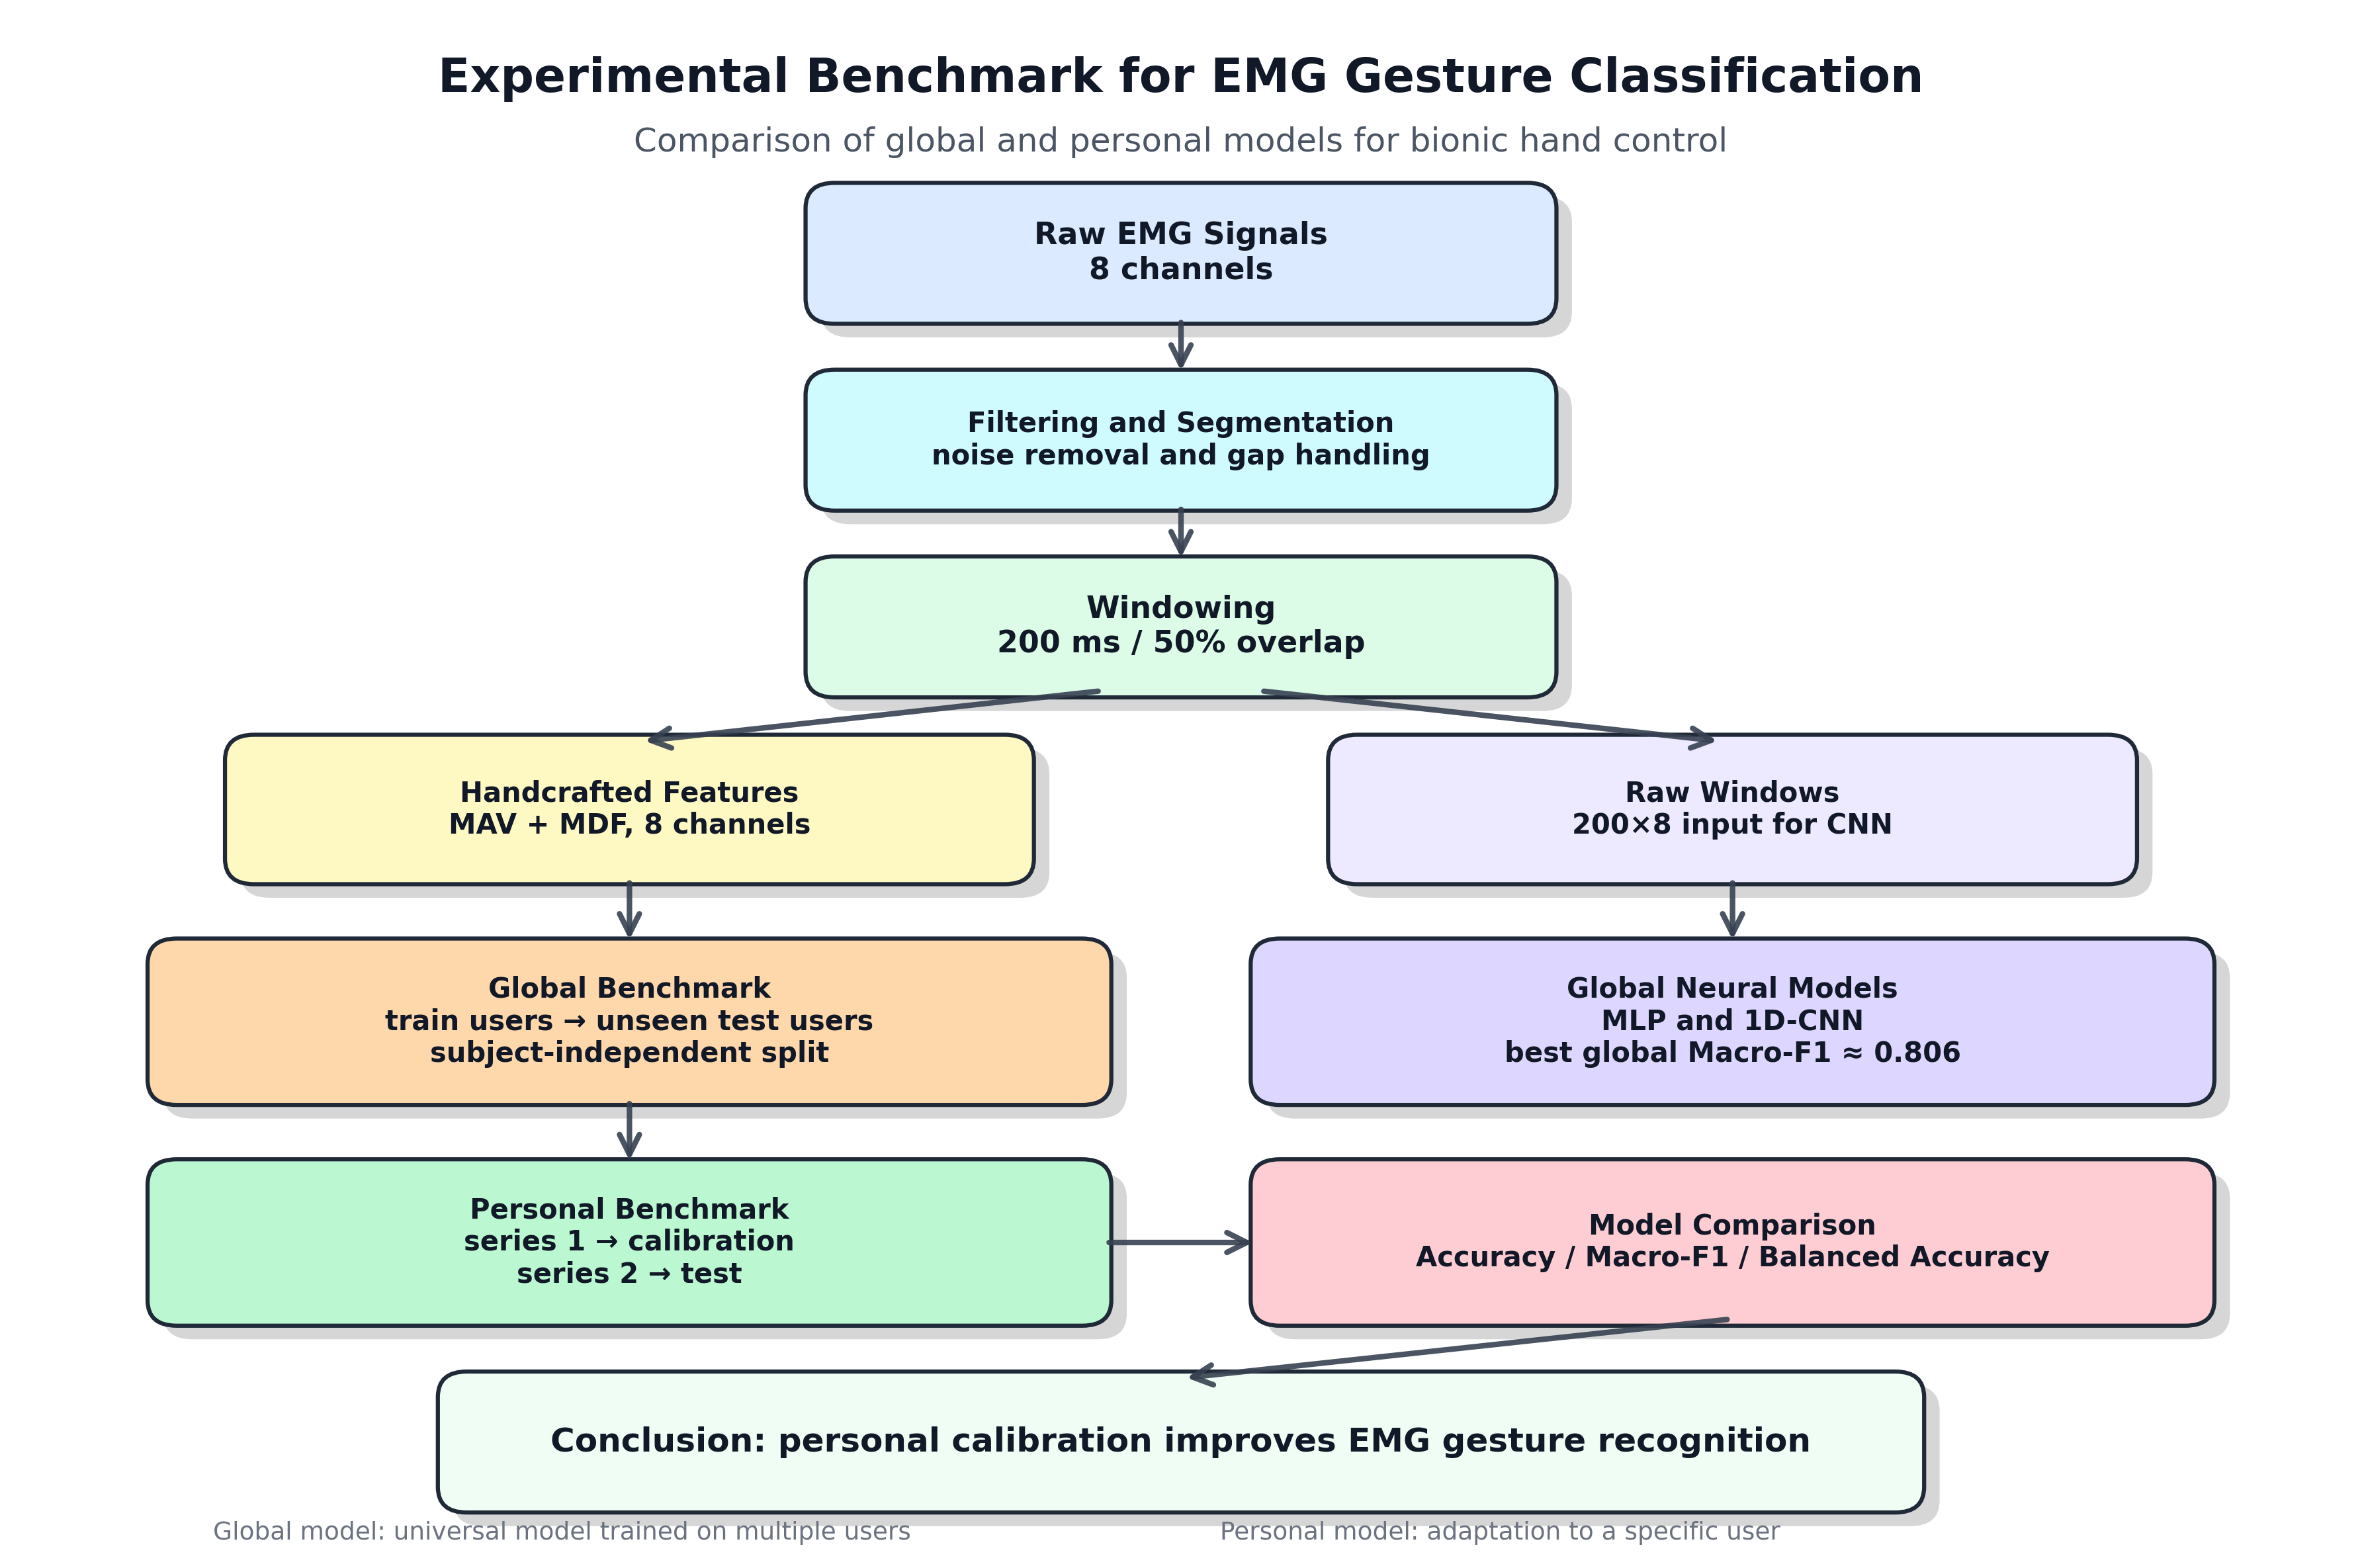

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Roboto', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
ax.set_xlim(0, 12)
ax.set_ylim(0, 9)
ax.axis("off")

def draw_box(x: float, y: float, w: float, h: float, text: str, color: str, edge: str = "#1f2937", fontsize: int = 11) -> None:
    """Отрисовывает блок с текстом и тенью."""

    shadow = FancyBboxPatch(
        (x + 0.08, y - 0.08), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.15",
        linewidth=0, facecolor="black", alpha=0.16
    )
    ax.add_patch(shadow)

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.15",
        linewidth=1.5, facecolor=color, edgecolor=edge
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight="bold", color="#111827"
    )

def draw_arrow(x1: float, y1: float, x2: float, y2: float, color: str = "#374151") -> None:
    """Отрисовывает направляющую стрелку между блоками."""
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=18,
        linewidth=2, color=color, alpha=0.9
    )
    ax.add_patch(arrow)

ax.text(6, 8.65, "Experimental Benchmark for EMG Gesture Classification",
        ha="center", va="center", fontsize=17, fontweight="bold", color="#111827")
ax.text(6, 8.28, "Comparison of global and personal models for bionic hand control",
        ha="center", va="center", fontsize=12, color="#4b5563")

draw_box(4.1, 7.25, 3.8, 0.75, "Raw EMG Signals\n8 channels", "#dbeafe")
draw_box(4.1, 6.15, 3.8, 0.75, "Filtering and Segmentation\nnoise removal and gap handling", "#cffafe", fontsize=10)
draw_box(4.1, 5.05, 3.8, 0.75, "Windowing\n200 ms / 50% overlap", "#dcfce7")

draw_arrow(6, 7.25, 6, 6.9)
draw_arrow(6, 6.15, 6, 5.8)

draw_box(1.1, 3.95, 4.1, 0.8, "Handcrafted Features\nMAV + MDF, 8 channels", "#fef9c3", fontsize=10)
draw_box(6.8, 3.95, 4.1, 0.8, "Raw Windows\n200×8 input for CNN", "#ede9fe", fontsize=10)

draw_arrow(5.6, 5.05, 3.2, 4.75)
draw_arrow(6.4, 5.05, 8.8, 4.75)

draw_box(0.7, 2.65, 4.9, 0.9, "Global Benchmark\ntrain users → unseen test users\nsubject-independent split", "#fed7aa", fontsize=10)
draw_box(6.4, 2.65, 4.9, 0.9, "Global Neural Models\nMLP and 1D-CNN\nbest global Macro-F1 ≈ 0.8085", "#ddd6fe", fontsize=10)

draw_arrow(3.15, 3.95, 3.15, 3.55)
draw_arrow(8.85, 3.95, 8.85, 3.55)

draw_box(0.7, 1.35, 4.9, 0.9, "Personal Benchmark\nseries 1 → calibration\nseries 2 → test", "#bbf7d0", fontsize=10)
draw_box(6.4, 1.35, 4.9, 0.9, "Model Comparison\nAccuracy / Macro-F1 / Balanced Accuracy", "#fecdd3", fontsize=10)

draw_arrow(3.15, 2.65, 3.15, 2.25)
draw_arrow(5.6, 1.8, 6.4, 1.8)

# Итог
draw_box(2.2, 0.25, 7.6, 0.75, "Conclusion: personal calibration improves EMG gesture recognition", "#f0fdf4", fontsize=12)

draw_arrow(8.85, 1.35, 6, 1.0)

ax.text(1.0, 0.05, "Global model: universal model trained on multiple users", fontsize=9, color="#6b7280")
ax.text(6.2, 0.05, "Personal model: adaptation to a specific user", fontsize=9, color="#6b7280")

plt.tight_layout()

Проведённый benchmark показал, что для EMG-классификации жестов глобальные нейросетевые модели способны достигать высокого качества при переносе на новых пользователей.* Среди глобальных моделей лучшей оказалась 1D-CNN на сырых EMG-окнах с Macro-F1 0.8085.*

Однако персональная калибровка оказалась более эффективной для конкретного пользователя. Лучшие персональные модели на признаках MAV и MDF превзошли глобальные baseline-модели в сценариях k = 5, 10, 20 и 40. При этом эффект персонализации был неодинаковым для разных пользователей: для части пользователей персональная модель дала значительный прирост, а для пользователей 17, 31 и 32 Personal Random Forest при k = 20 уступил лучшему глобальному baseline.

Практическое применение полученных результатов заключается в построении гибридной схемы управления бионическим протезом. На начальном этапе может использоваться глобальная модель, обученная на данных разных пользователей. Она обеспечивает базовое распознавание жестов без индивидуальной настройки. После короткой калибровочной процедуры для конкретного пользователя строится персональная модель на признаках MAV и MDF. Эксперименты показали, что такая персональная калибровка повышает Macro-F1 примерно на 9–11 процентных пунктов по сравнению с глобальной моделью. Поэтому для реальной системы целесообразно использовать глобальную модель как стартовую, а затем адаптировать управление протезом с помощью персональной модели.

## 11.EMG Analyzer APP

В рамках практической части работы было разработано локальное приложение EMG Signal Analyzer, предназначенное для предварительной диагностики качества EMG-записей. Приложение реализовано на Python с использованием библиотеки Gradio и запускается локально на компьютере пользователя. Оно принимает на вход EMG-файлы в формате `.txt` или `.csv`, содержащие временную метку, восемь каналов сигнала и метку жеста.

Основная задача приложения заключается не в классификации жестов, а в оценке пригодности EMG-записи для дальнейшей обработки, обучения моделей и персональной калибровки. После загрузки файла приложение выполняет очистку данных, проверяет корректность числовых значений, оценивает частоту дискретизации, выявляет временные разрывы, анализирует активность каналов и определяет возможные подозрительные участки сигнала.

Для каждого EMG-канала рассчитываются статистические характеристики, включая среднее значение, стандартное отклонение, RMS, MAV, амплитудный диапазон, долю возможных flatline-участков и процент амплитудных выбросов. Также приложение оценивает распределение меток жестов и количество валидных временных окон длительностью 200 ms. Это позволяет быстро определить, содержит ли запись достаточное количество данных для анализа основных жестов.

Результаты анализа отображаются в виде таблиц и графиков: общего обзора файла, диагностических индикаторов, предварительного просмотра сигнала, активности каналов, распределения меток и списка подозрительных интервалов. Такой формат делает приложение удобным инструментом для первичного контроля качества EMG-данных перед запуском моделей машинного обучения.

Разработанное приложение можно рассматривать как вспомогательный модуль в системе распознавания EMG-жестов. Оно повышает надёжность последующих этапов анализа, поскольку позволяет заранее обнаружить проблемы с сигналом: пропуски, временные разрывы, выбросы, неактивные каналы или неполное покрытие классов жестов.

## 12.References

[Хабр. Разрабатываем бионический протез руки с нуля](https://habr.com/ru/articles/572146/)

[DP Labs про бионический протез](https://www.youtube.com/watch?v=6lqhSErrFUM)

[DP Labs](https://www.youtube.com/watch?v=Weg_HnRnbzM)

[Машинное обучение в биологии. Лекции](https://www.youtube.com/watch?v=0W1MEXUhTuU&list=PLcsjsqLLSfNByvZYyo18kznrisI1WDkiI&index=2)

[Казнин А., Миляев Н. Анализ современных систем управления биоэлектрическими протезами](https://docs.yandex.ru/docs/view?tm=1781323818&tld=ru&lang=ru&name=201.pdf&text=bebionic%20протезы%20articles%20ai&url=https%3A%2F%2Felib.institutemvd.by%2Fbitstream%2FMVD_NAM%2F986%2F1%2F201.pdf&lr=47&mime=pdf&l10n=ru&sign=36f58d35d9c50b17342110cf811ded82&keyno=0&nosw=1&serpParams=tm%3D1781323818%26tld%3Dru%26lang%3Dru%26name%3D201.pdf%26text%3Dbebionic%2B%25D0%25BF%25D1%2580%25D0%25BE%25D1%2582%25D0%25B5%25D0%25B7%25D1%258B%2Barticles%2Bai%26url%3Dhttps%253A%2F%2Felib.institutemvd.by%2Fbitstream%2FMVD_NAM%2F986%2F1%2F201.pdf%26lr%3D47%26mime%3Dpdf%26l10n%3Dru%26sign%3D36f58d35d9c50b17342110cf811ded82%26keyno%3D0%26nosw%3D1)

[Андреев А. А. Нейросетевые методы управления бионическими протезами верхней конечности на основе классификации электромиографических сигналов // Актуальные исследования. 2026. №13 (299).](https://apni.ru/article/14728-nejrosetevye-metody-upravleniya-bionicheskimi-protezami-verhnej-konechnosti-na-osnove-klassifikacii-elektromiograficheskih-signalov)

Zhou Y., Chen C., Ni J., Ni G., Li M., Xu G., Cavanaugh J., Cheng M., Lemos S. EMG Signal Processing for Hand Motion Pattern Recognition Using Machine Learning Algorithms // Archives of Orthopaedics. 2020. Vol. 1. No. 1. P. 17–26.



